# 🛒 PRACTICE 2: Predicting Product Sales
**Dataset:** [Kaggle Store Sales - Time Series Forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting)

---

## Problem Statement

Predict **daily unit sales** for thousands of product families sold at Favorita grocery stores in Ecuador.  
The evaluation metric used by Kaggle is **Root Mean Squared Logarithmic Error (RMSLE)**:

$$\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( \log(1 + \hat{y}_i) - \log(1 + y_i) \right)^2}$$

Using $\log(1+y)$ instead of $y$ handles zero-sales days and penalizes under-prediction/over-prediction symmetrically on a relative scale.

## Forecasting Strategy — Sliding Window

Instead of a direct multi-step forecast, we use a **recursive sliding window** of length $W = 7$:

$$\hat{y}_t = f\bigl(y_{t-1},\, y_{t-2},\, \ldots,\, y_{t-W}\bigr)$$

| Step | Window used | Predicts |
|------|-------------|----------|
| 1 | days 1 – 7 | day 8 |
| 2 | days 2 – 8 | day 9 |
| 3 | days 3 – 9 | day 10 |
| … | … | … |

Each prediction is **fed back** into the window to produce the next one — this is the recursive (autoregressive) approach.

## Files Used
| File | Description |
|------|-------------|
| `train.csv` | Historical sales by date, store, product family |
| `test.csv` | Future dates to predict |
| `stores.csv` | Store metadata (city, state, type, cluster) |
| `holidays_events.csv` | National / regional holidays and events |
| `oil.csv` | Daily oil price (Ecuador's economy is oil-dependent) |

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [4]:
# Load các file
train_data = pd.read_csv("./store-sales-time-series-forecasting/train.csv")
transaction_data = pd.read_csv("./store-sales-time-series-forecasting/transactions.csv")
stores_data = pd.read_csv("./store-sales-time-series-forecasting/stores.csv")
holiday_data = pd.read_csv("./store-sales-time-series-forecasting/holidays_events.csv")
oil_data = pd.read_csv("./store-sales-time-series-forecasting/oil.csv")

# 1. Train Data

In [5]:
train_data['date'] = pd.to_datetime(train_data['date'])
train_data = train_data.set_index('date')
train_data = train_data.drop('id' , axis=1)
train_data.head(5)

,store_nbr,family,sales,onpromotion
date,,,,
2013-01-01,1,AUTOMOTIVE,0.0,0
2013-01-01,1,BABY CARE,0.0,0
2013-01-01,1,BEAUTY,0.0,0
2013-01-01,1,BEVERAGES,0.0,0
2013-01-01,1,BOOKS,0.0,0


In [6]:
print(train_data.info())
print("=="*30)
print(train_data.describe())
print("=="*30)
print(f"Family Unique: {len(train_data['family'].unique())}")
print(f"Stores Unique: {len(train_data['store_nbr'].unique())}")
print("=="*30)
print(f"Missing Value: \n{train_data.isna().sum()}")

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3000888 entries, 2013-01-01 to 2017-08-15
Data columns (total 4 columns):
 #   Column       Dtype  
---  ------       -----  
 0   store_nbr    int64  
 1   family       object 
 2   sales        float64
 3   onpromotion  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 114.5+ MB
None
          store_nbr         sales   onpromotion
count  3.000888e+06  3.000888e+06  3.000888e+06
mean   2.750000e+01  3.577757e+02  2.602770e+00
std    1.558579e+01  1.101998e+03  1.221888e+01
min    1.000000e+00  0.000000e+00  0.000000e+00
25%    1.400000e+01  0.000000e+00  0.000000e+00
50%    2.750000e+01  1.100000e+01  0.000000e+00
75%    4.100000e+01  1.958473e+02  0.000000e+00
max    5.400000e+01  1.247170e+05  7.410000e+02
Family Unique: 33
Stores Unique: 54
Missing Value: 
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


In [7]:
# Kiểm tra khoảng cách giữa các ngày trong dữ liệu
def count_day_gap(df):
    temp = df.reset_index().groupby(['date']).sales.sum()
    return (temp.index[1:]-temp.index[:-1]).value_counts()

count_day_gap(train_data)

date
1 days    1679
2 days       4
Name: count, dtype: int64

In [8]:
temp = train_data.reset_index().groupby(['date']).sales.sum().to_frame()
gap = (temp.index[1:]-temp.index[:-1]).to_list()
gap.insert(0,'first day') 
temp['gap'] = gap

day_skip = temp.groupby('gap').get_group(temp.gap.unique()[2])
day_skip

,sales,gap
date,,
2013-12-26,4.707312e+05,2 days 00:00:00
2014-12-26,8.720985e+05,2 days 00:00:00
2015-12-26,9.467252e+05,2 days 00:00:00
2016-12-26,1.032771e+06,2 days 00:00:00


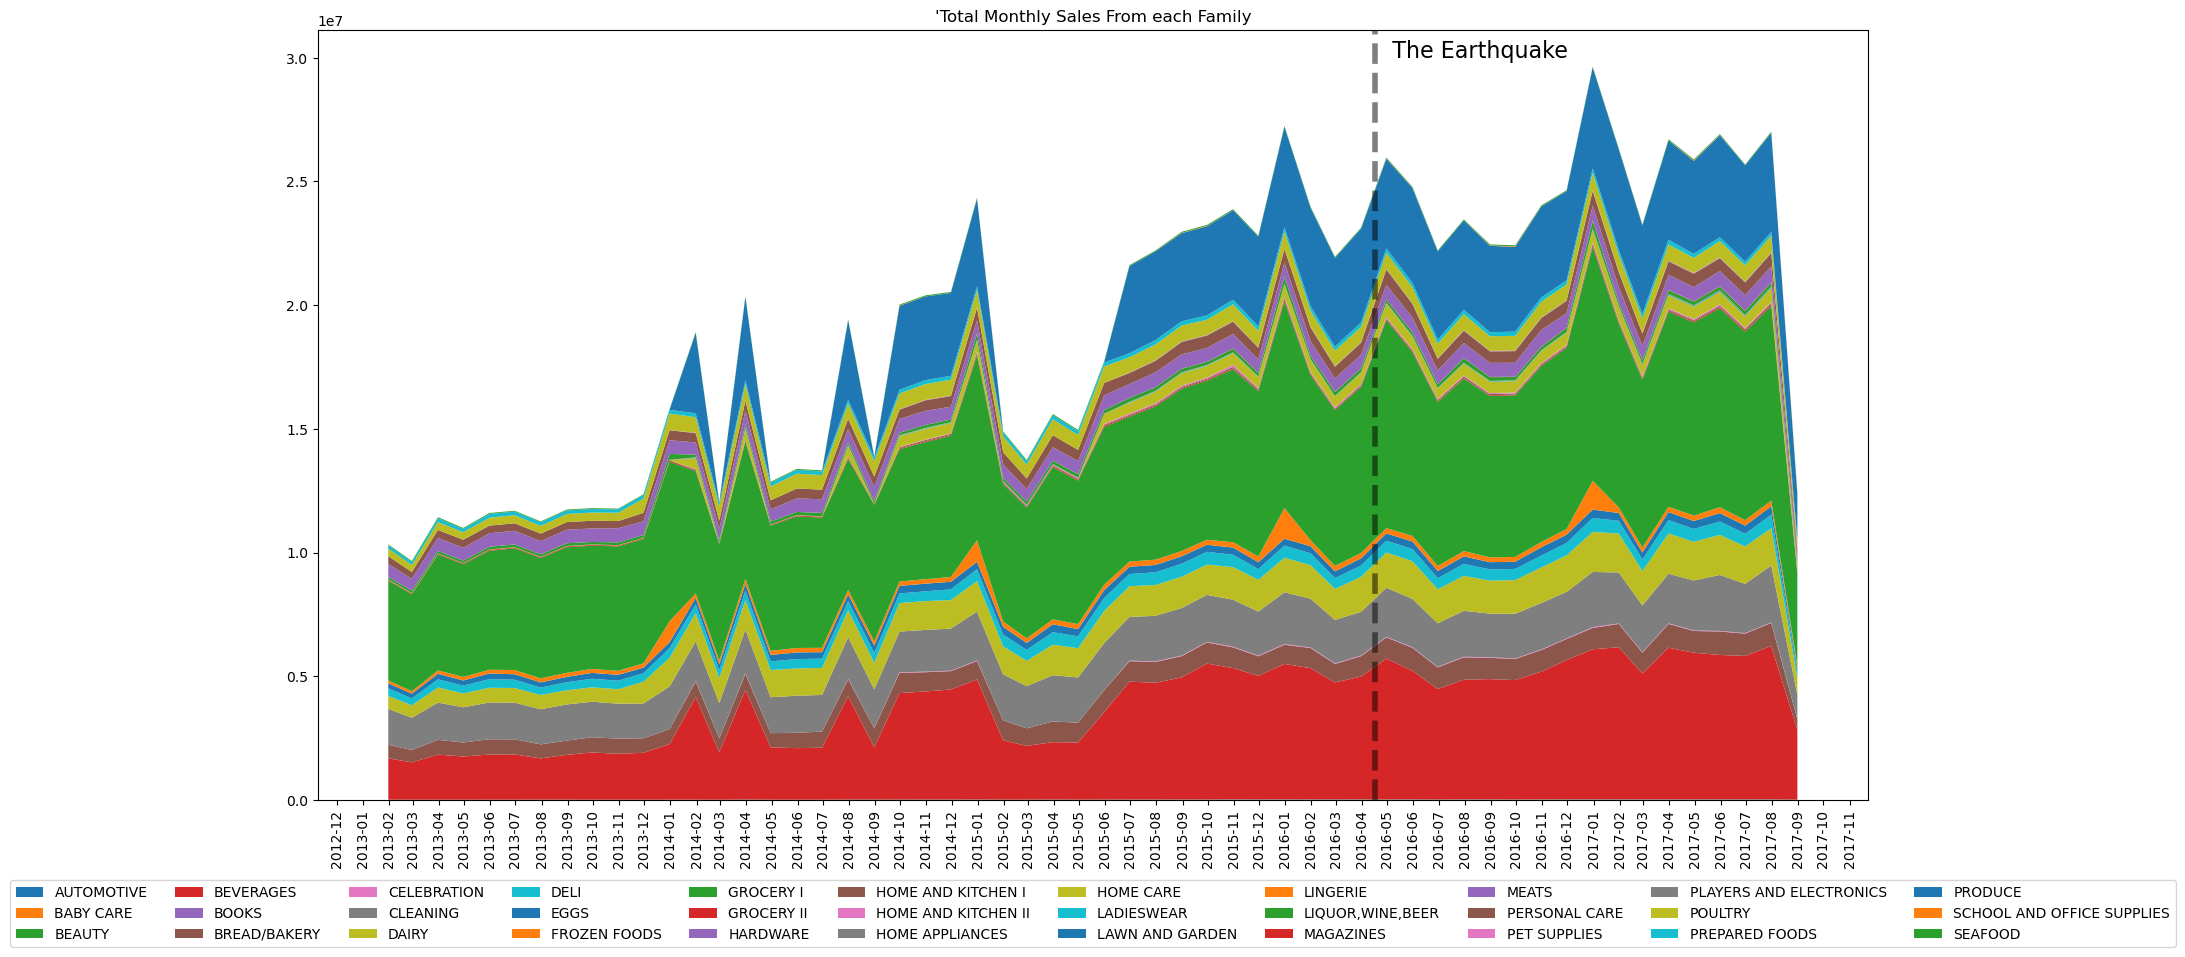

In [9]:
# 1.Tổng doanh thu theo tháng-năm của từng sản phẩm
date_fam_sale = train_data.groupby(['date','family']).sum().sales
unstack = date_fam_sale.unstack()
unstack = unstack.resample('ME').sum()

fig, ax = plt.subplots(figsize=(20, 10))
ax.set(title="'Total Monthly Sales From each Family")
plt.stackplot(unstack.index,unstack.T,labels=unstack.T.index)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.axvline(x=pd.Timestamp('2016-04-16'),color='black',linestyle='--',linewidth=4,alpha=0.5)
plt.text(pd.Timestamp('2016-04-20'),30000000,'  The Earthquake',rotation=360,c='black',size=16)
plt.xticks(rotation=90)
plt.legend(loc='lower center',bbox_to_anchor=(0.5,-0.2),ncol=11)
plt.show()

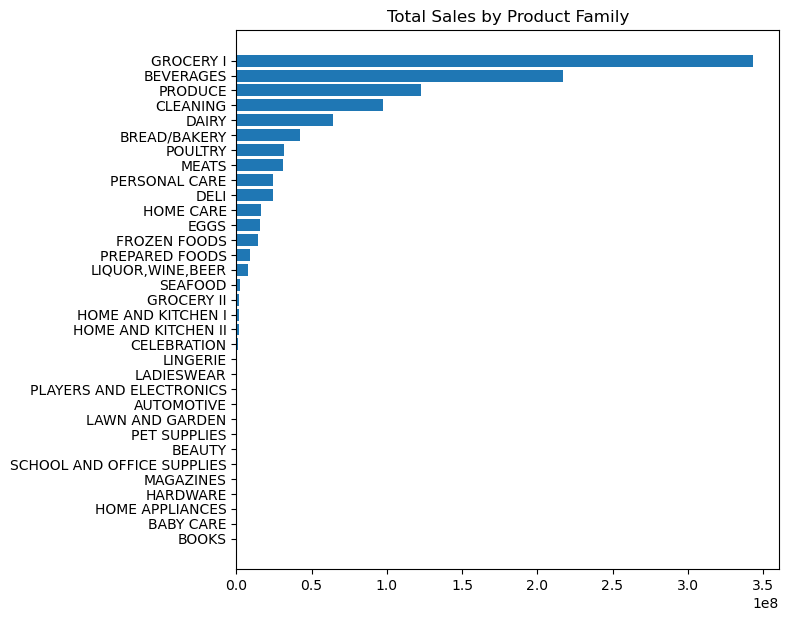

In [10]:
# 2.Top các sản phẩm bán chạy nhất
month_family = train_data.groupby('family').resample('ME').sales.sum() 

fig, ax = plt.subplots(figsize=(7,7))
plt.barh(month_family.groupby('family').sum().sort_values().index,month_family.groupby('family').sum().sort_values())
ax.set(title='Total Sales by Product Family')
plt.show()

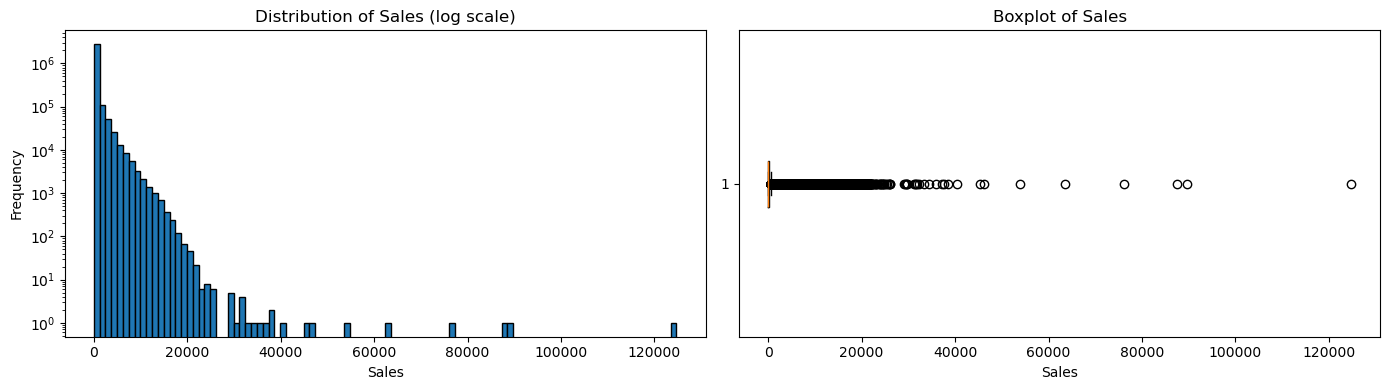

In [11]:
# 3.Phân phối của biến target 'sales'
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train_data['sales'], bins=100, log=True, edgecolor='black')
axes[0].set_title('Distribution of Sales (log scale)')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(train_data['sales'], vert=False)
axes[1].set_title('Boxplot of Sales')
axes[1].set_xlabel('Sales')
plt.tight_layout()
plt.show()

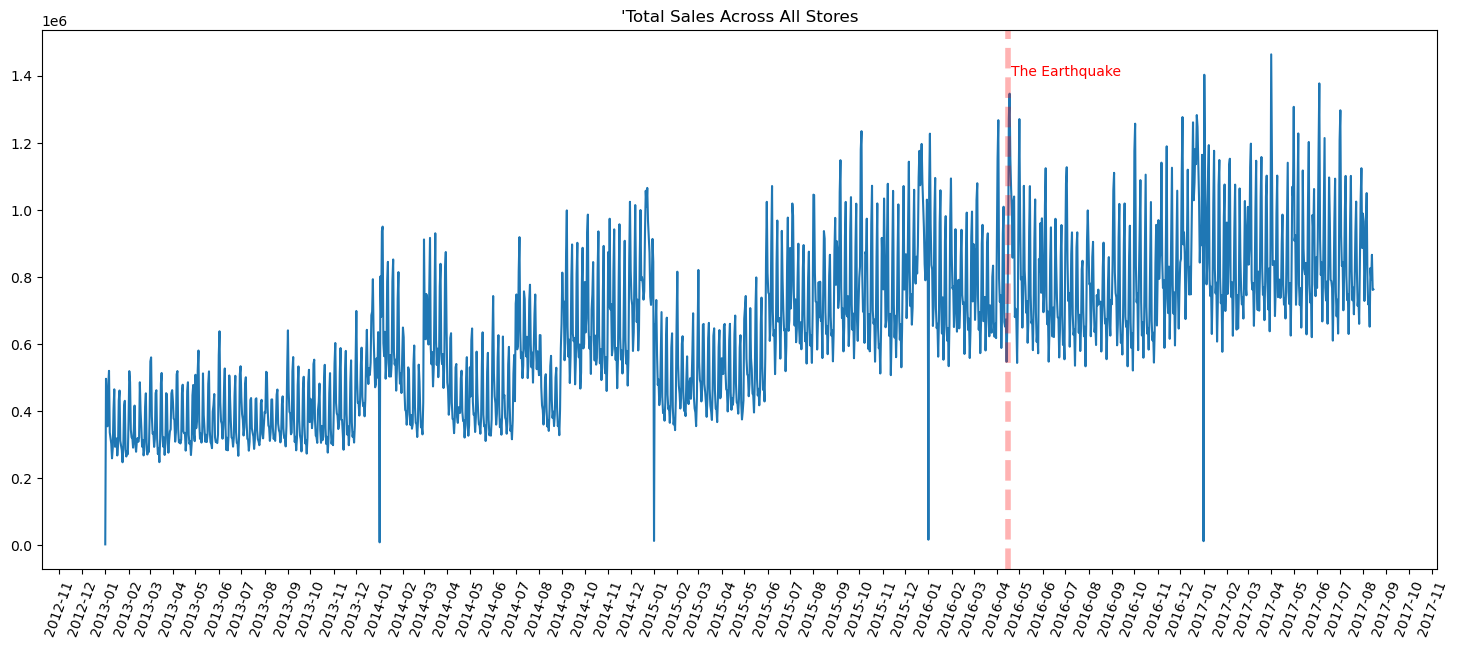

In [12]:
# 4. Sales theo thời gian (tổng doanh số mỗi ngày)
fig, ax = plt.subplots(figsize=(18, 7))
ax.set(title="'Total Sales Across All Stores")
total_sales = train_data.sales.groupby("date").sum()
plt.plot(total_sales)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=70)
plt.axvline(x=pd.Timestamp('2016-04-16'),color='r',linestyle='--',linewidth=4,alpha=0.3)
plt.text(pd.Timestamp('2016-04-20'),1400000,'The Earthquake',rotation=360,c='r')
plt.show()

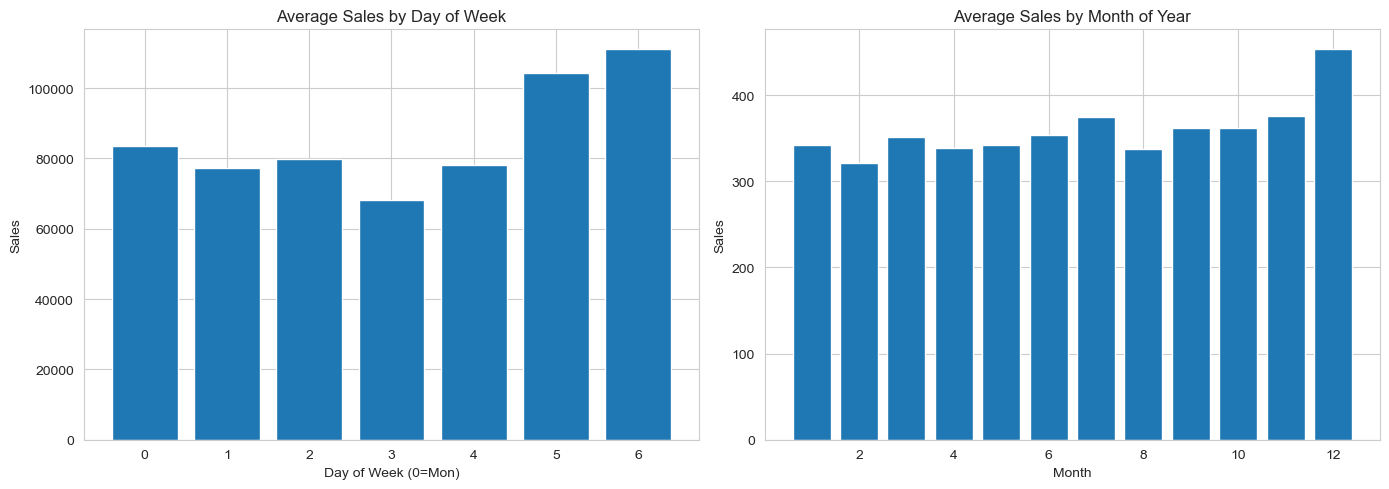

In [13]:
def plot_time_patterns():
    sns.set_style("whitegrid")

    # ----- Day of week -----
    day_group = train_data.reset_index()[['date','sales']]
    day_group = day_group.groupby('date').sales.mean().to_frame()
    day_group['dow'] = day_group.index.dayofweek
    dow_sales = day_group.groupby('dow').sales.sum()

    # ----- Month of year -----
    month_group = train_data['sales'].to_frame()
    month_group['moy'] = month_group.index.month
    moy_sales = month_group.groupby('moy').sales.mean()

    # ----- Plot -----
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Biểu đồ theo ngày trong tuần
    axes[0].bar(dow_sales.index, dow_sales.values)
    axes[0].set_title("Average Sales by Day of Week", fontsize=12)
    axes[0].set_xlabel("Day of Week (0=Mon)")
    axes[0].set_ylabel("Sales")

    # Biểu đồ theo tháng
    axes[1].bar(moy_sales.index, moy_sales.values)
    axes[1].set_title("Average Sales by Month of Year", fontsize=12)
    axes[1].set_xlabel("Month")
    axes[1].set_ylabel("Sales")

    plt.tight_layout()
    plt.show()

plot_time_patterns()

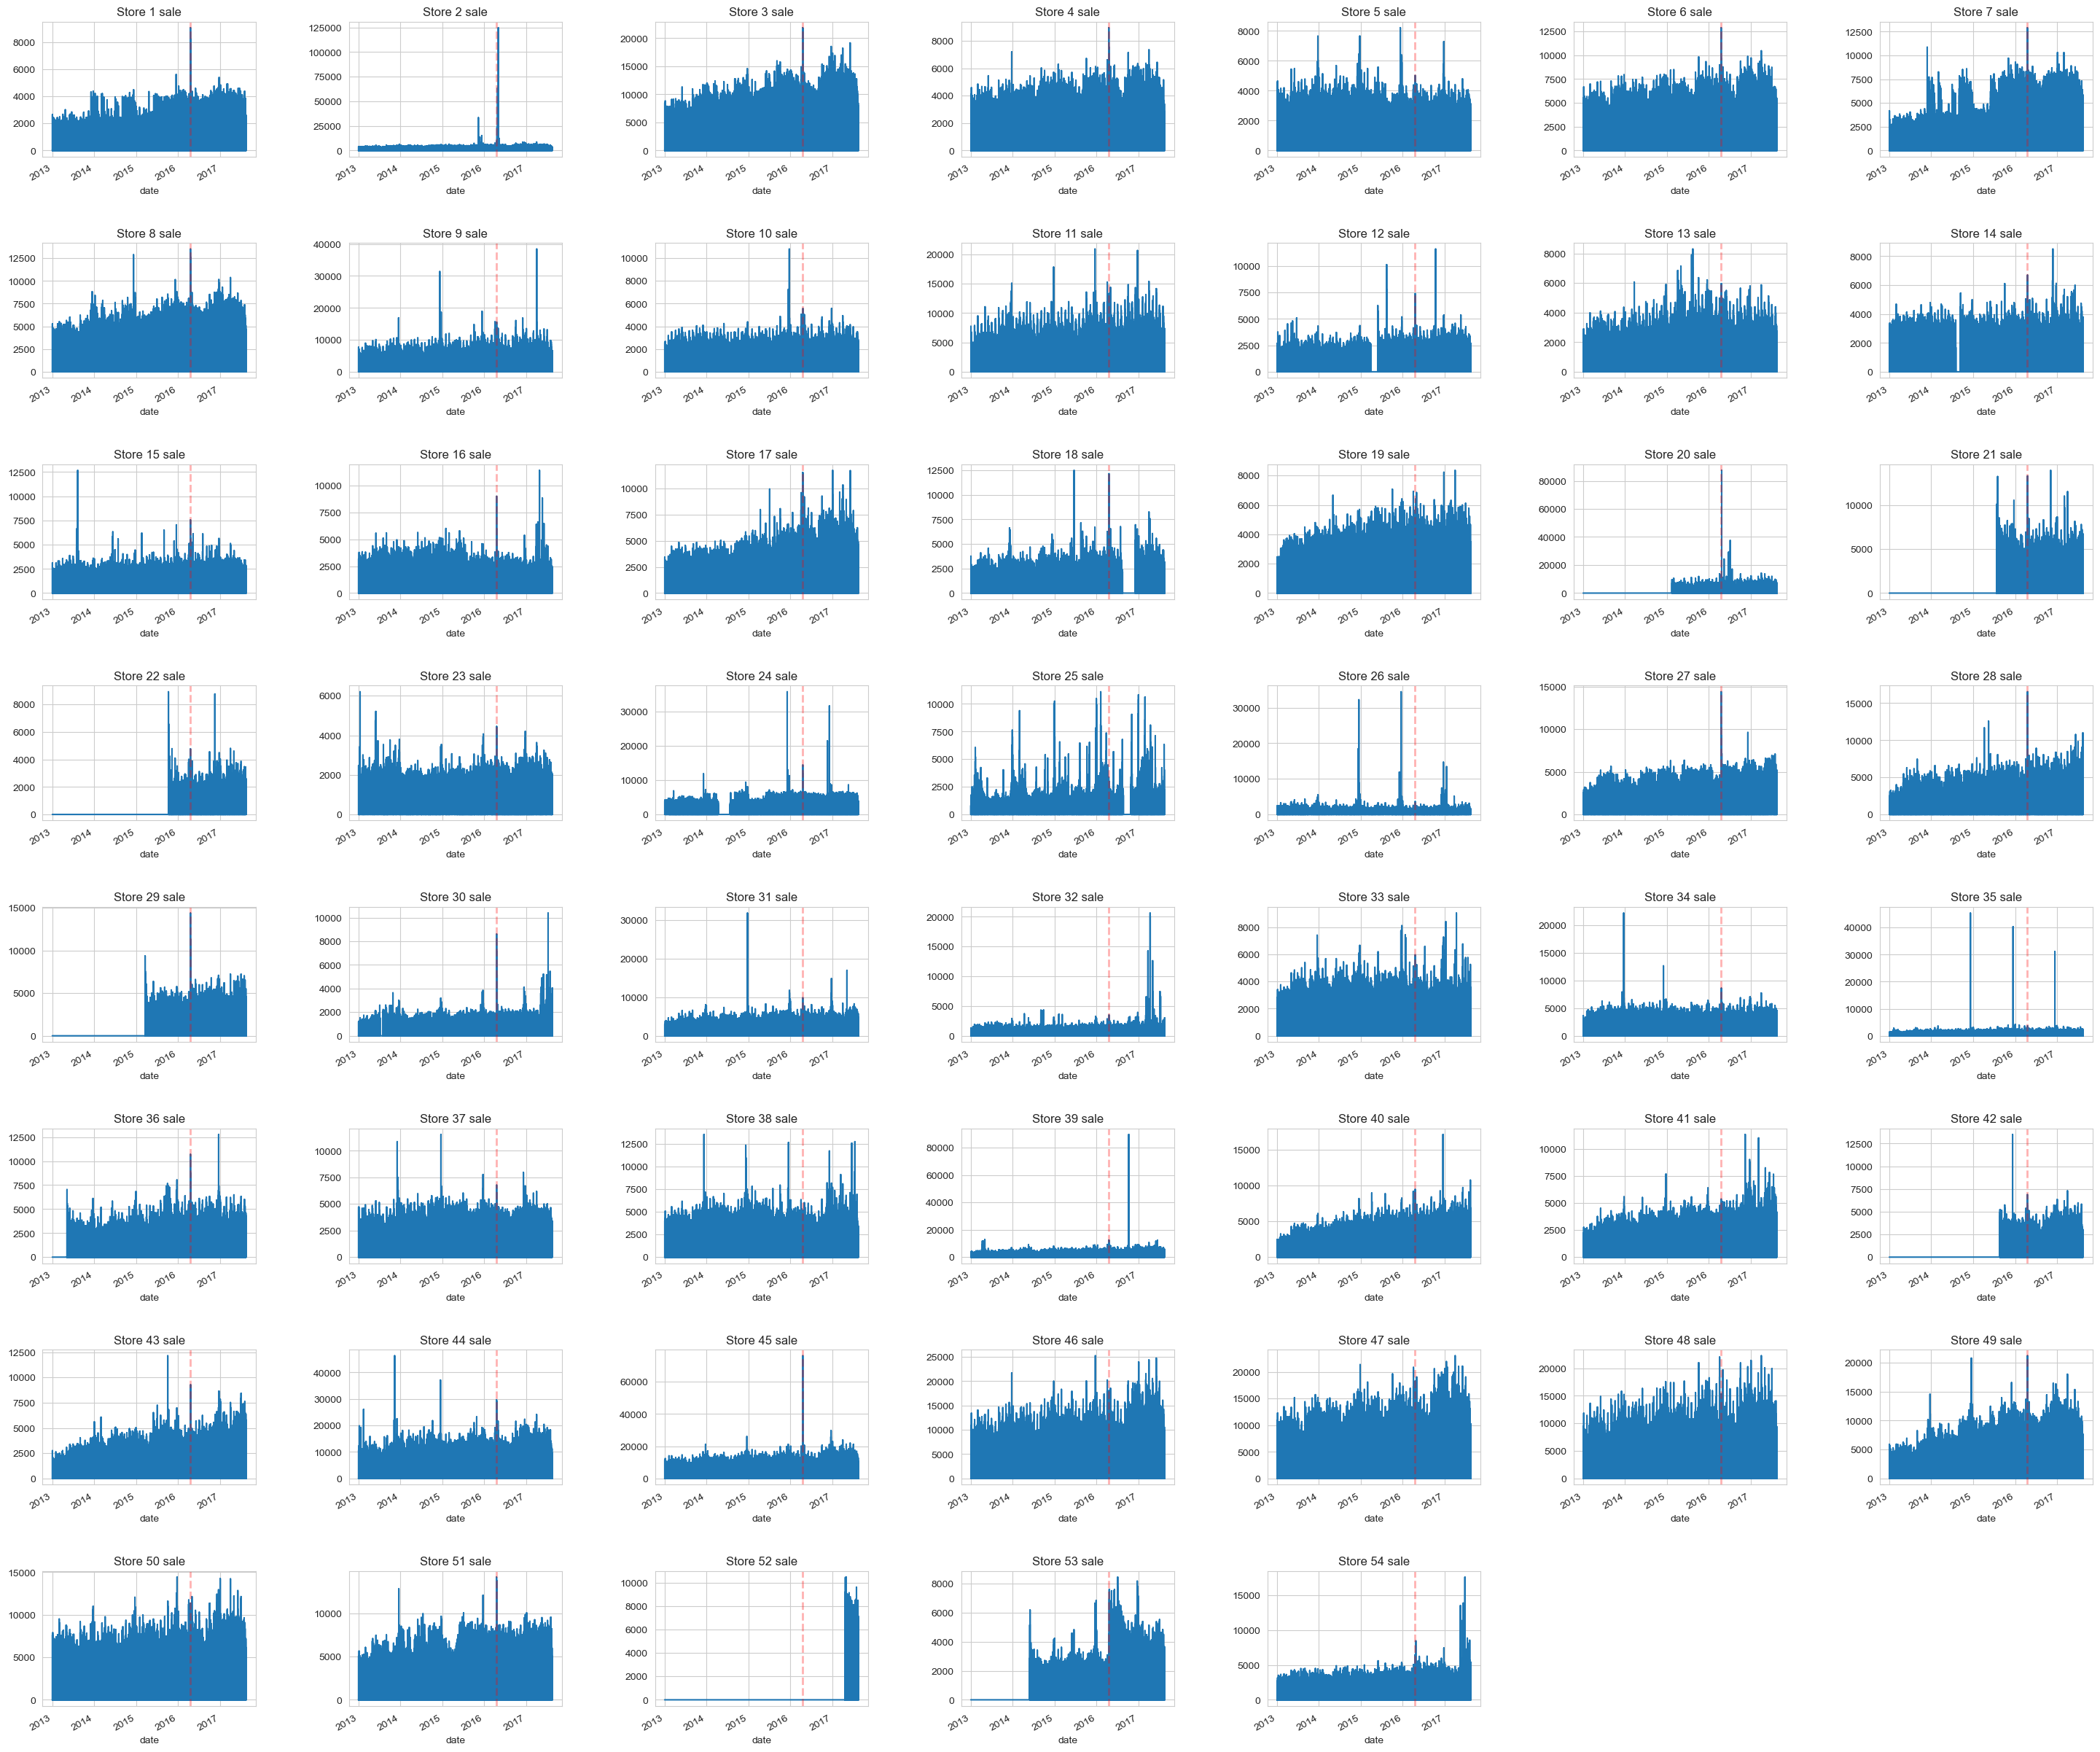

In [14]:
# 5. Doanh thu theo từng cửa hàng
daily_sale_dict = {}
for i in train_data.store_nbr.unique():
    daily_sale = train_data[train_data['store_nbr']==i]
    daily_sale_dict[i] = daily_sale

fig = plt.figure(figsize=(30,30))
for i in daily_sale_dict.keys():
    plt.subplot(8,7,i)
    plt.title('Store {} sale'.format(i))
    plt.tight_layout(pad=5)
    sale = daily_sale_dict[i].sales
    sale.plot()
    plt.axvline(x=pd.Timestamp('2016-04-16'),color='r',linestyle='--',linewidth=2,alpha=0.3) # Hôm xảy ra động đất

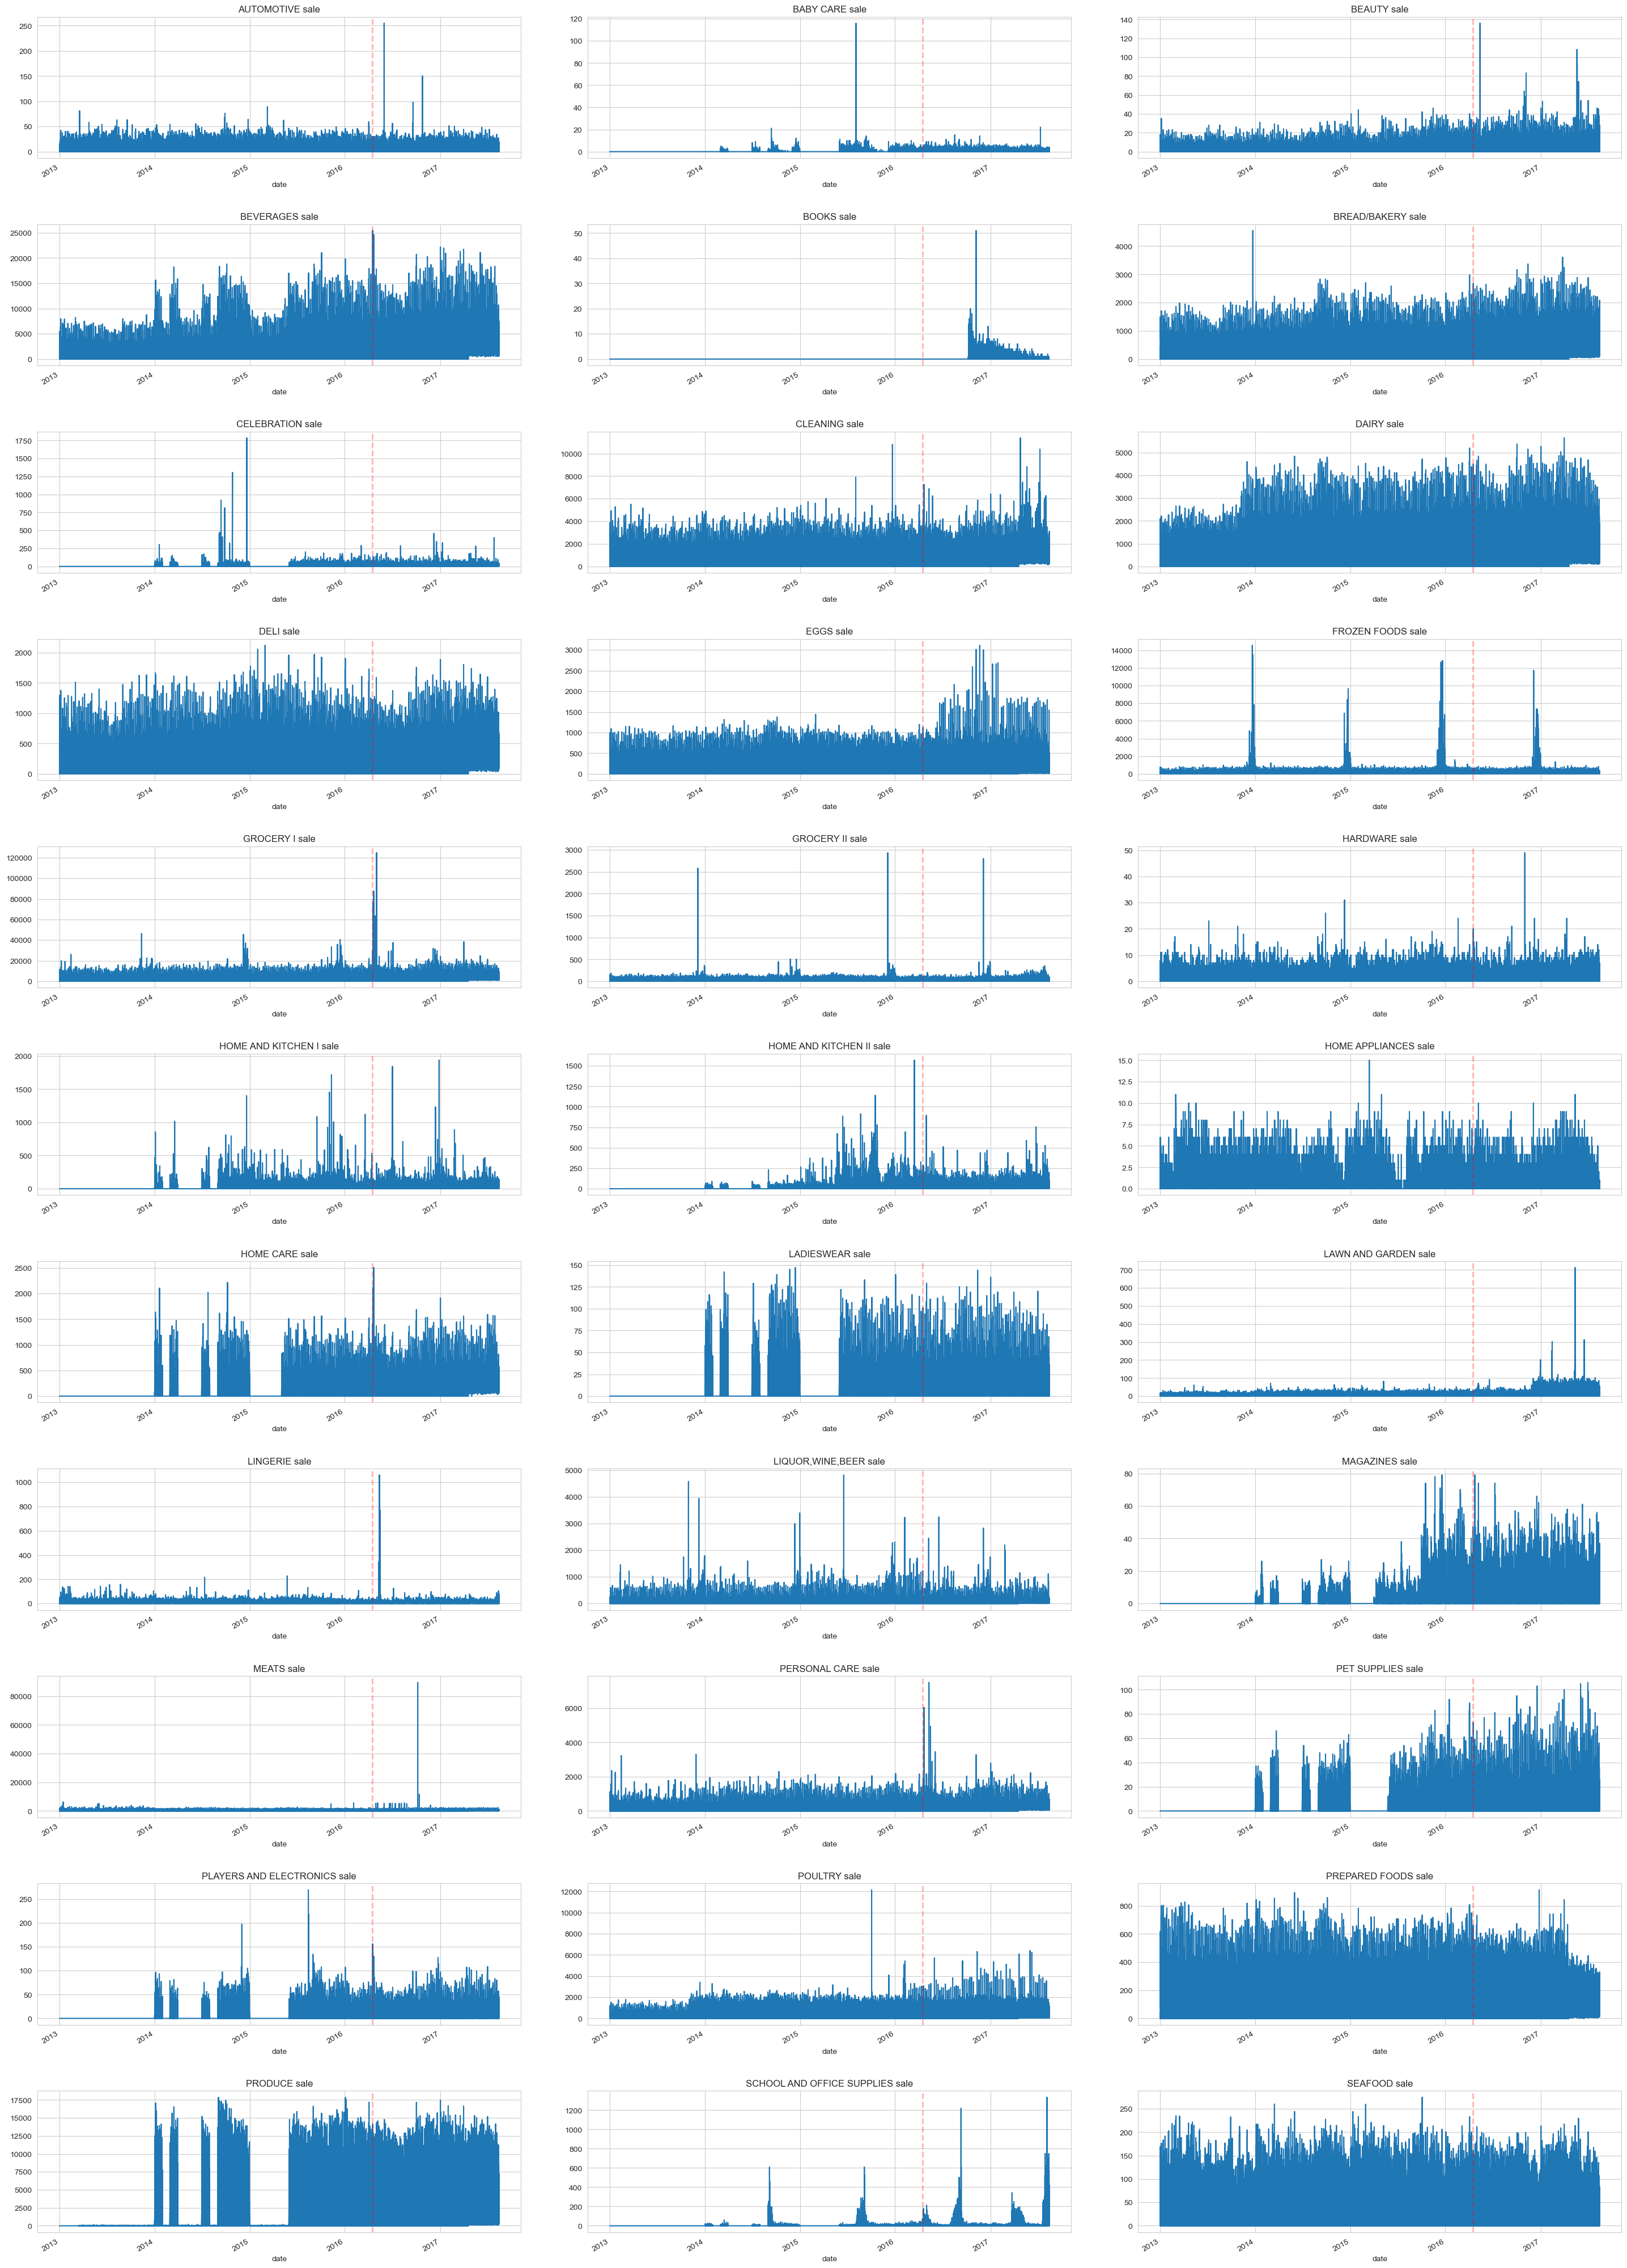

In [15]:
# 6. Doanh thu của từng loại sản phẩm theo thời gian
by_fam_dic = {}
fam_list = train_data.family.unique()

for fam in fam_list:
    by_fam_dic[fam] = train_data[train_data['family']==fam].sales

fig = plt.figure(figsize=(30,50))

for i,fam in enumerate(by_fam_dic.keys()):
    plt.subplot(11,3,i+1)
    plt.title('{} sale'.format(fam))
    plt.tight_layout(pad=5)
    sale = by_fam_dic[fam]
    sale.plot()
    plt.axvline(x=pd.Timestamp('2016-04-16'),color='r',linestyle='--',linewidth=2,alpha=0.3) #mark the earthquake

In [16]:
print('hệ số tương quan Spearman = {}'.format(
    train_data.sales.corr(train_data.onpromotion,method='spearman')))

hệ số tương quan Spearman = 0.5380218163559218


# 2. Stores Data

In [17]:
stores_data.head(5)


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [18]:
print(stores_data.info())
print("=="*30)
print(stores_data.describe())
print("=="*30)
print(f"Family Unique: {len(stores_data['city'].unique())}")
print(f"state Unique: {len(stores_data['state'].unique())}")
print(f"type Unique: {len(stores_data['type'].unique())}")
print("=="*30)
print(f"Missing Value: \n{stores_data.isna().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB
None
       store_nbr    cluster
count  54.000000  54.000000
mean   27.500000   8.481481
std    15.732133   4.693395
min     1.000000   1.000000
25%    14.250000   4.000000
50%    27.500000   8.500000
75%    40.750000  13.000000
max    54.000000  17.000000
Family Unique: 22
state Unique: 16
type Unique: 5
Missing Value: 
store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64


In [19]:
join_df = train_data.merge(stores_data,on='store_nbr')
join_df.set_index(train_data.index)
join_df['date'] = train_data.index
join_df = join_df.set_index('date')

join_df.head()

,store_nbr,family,sales,onpromotion,city,state,type,cluster
date,,,,,,,,
2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13
2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13
2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13
2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13


In [20]:
def show_type_df(join_store_type_df):
    mean_sales_type = join_store_type_df.groupby('type').sales.mean()
    median_sales_type = join_store_type_df.groupby('type').sales.median()
    number=join_store_type_df.groupby('type').store_nbr.nunique()

    type_df = pd.DataFrame((mean_sales_type,median_sales_type,number))
    type_df = type_df.T
    type_df.columns = ['mean','median','number of store']

    return type_df

def show_cluster_summary(join_store_type_df):
    mean_sales_cluster = join_store_type_df.groupby('cluster').sales.mean()
    median_sales_cluster = join_store_type_df.groupby('cluster').sales.median()
    number=join_store_type_df.groupby('cluster').store_nbr.nunique()

    cluster_df = pd.DataFrame((mean_sales_cluster,median_sales_cluster,number))
    cluster_df = cluster_df.T
    cluster_df.columns = ['mean','median','number of store']

    return cluster_df.sort_values('mean', ascending=False)

def show_city_df(join_store_type_df):    
    mean_sales_city = join_store_type_df.groupby('city').sales.mean()
    median_sales_city = join_store_type_df.groupby('city').sales.median()
    number=join_store_type_df.groupby('city').store_nbr.nunique()

    city_df = pd.DataFrame((mean_sales_city,median_sales_city,number))
    city_df = city_df.T
    city_df.columns = ['mean','median','number of store']

    return city_df.sort_values('mean', ascending=False)

In [21]:
show_type_df(join_df)

,mean,median,number of store
type,,,
A,705.878743,24.0,9.0
B,326.739714,7.0,8.0
C,197.263301,5.0,15.0
D,350.979407,16.0,18.0
E,269.121301,4.0,4.0


In [22]:
show_cluster_summary(join_df)

,mean,median,number of store
cluster,,,
5,1117.245254,75.0,1.0
14,708.227718,36.0,4.0
8,647.377856,42.0,3.0
11,603.507018,5.0,3.0
17,592.231511,27.0,1.0
6,342.661732,7.0,6.0
1,326.163967,15.0,3.0
12,324.461406,10.0,1.0
13,324.364108,14.0,4.0


In [23]:
show_city_df(join_df)

,mean,median,number of store
city,,,
Quito,556.577090,24.0,18.0
Cayambe,509.709179,15.0,1.0
Ambato,362.632273,21.0,2.0
Daule,345.282181,18.0,1.0
Loja,339.379530,22.0,1.0
Babahoyo,319.349181,10.0,1.0
Machala,300.392253,13.0,2.0
Esmeraldas,294.963151,7.0,1.0
Cuenca,294.924279,8.0,3.0


C:\Users\THIEN\AppData\Local\Temp\ipykernel_25972\474665201.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a["ind"] = 1
C:\Users\THIEN\AppData\Local\Temp\ipykernel_25972\474665201.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a["ind"] = a.groupby("store_nbr").ind.cumsum().values


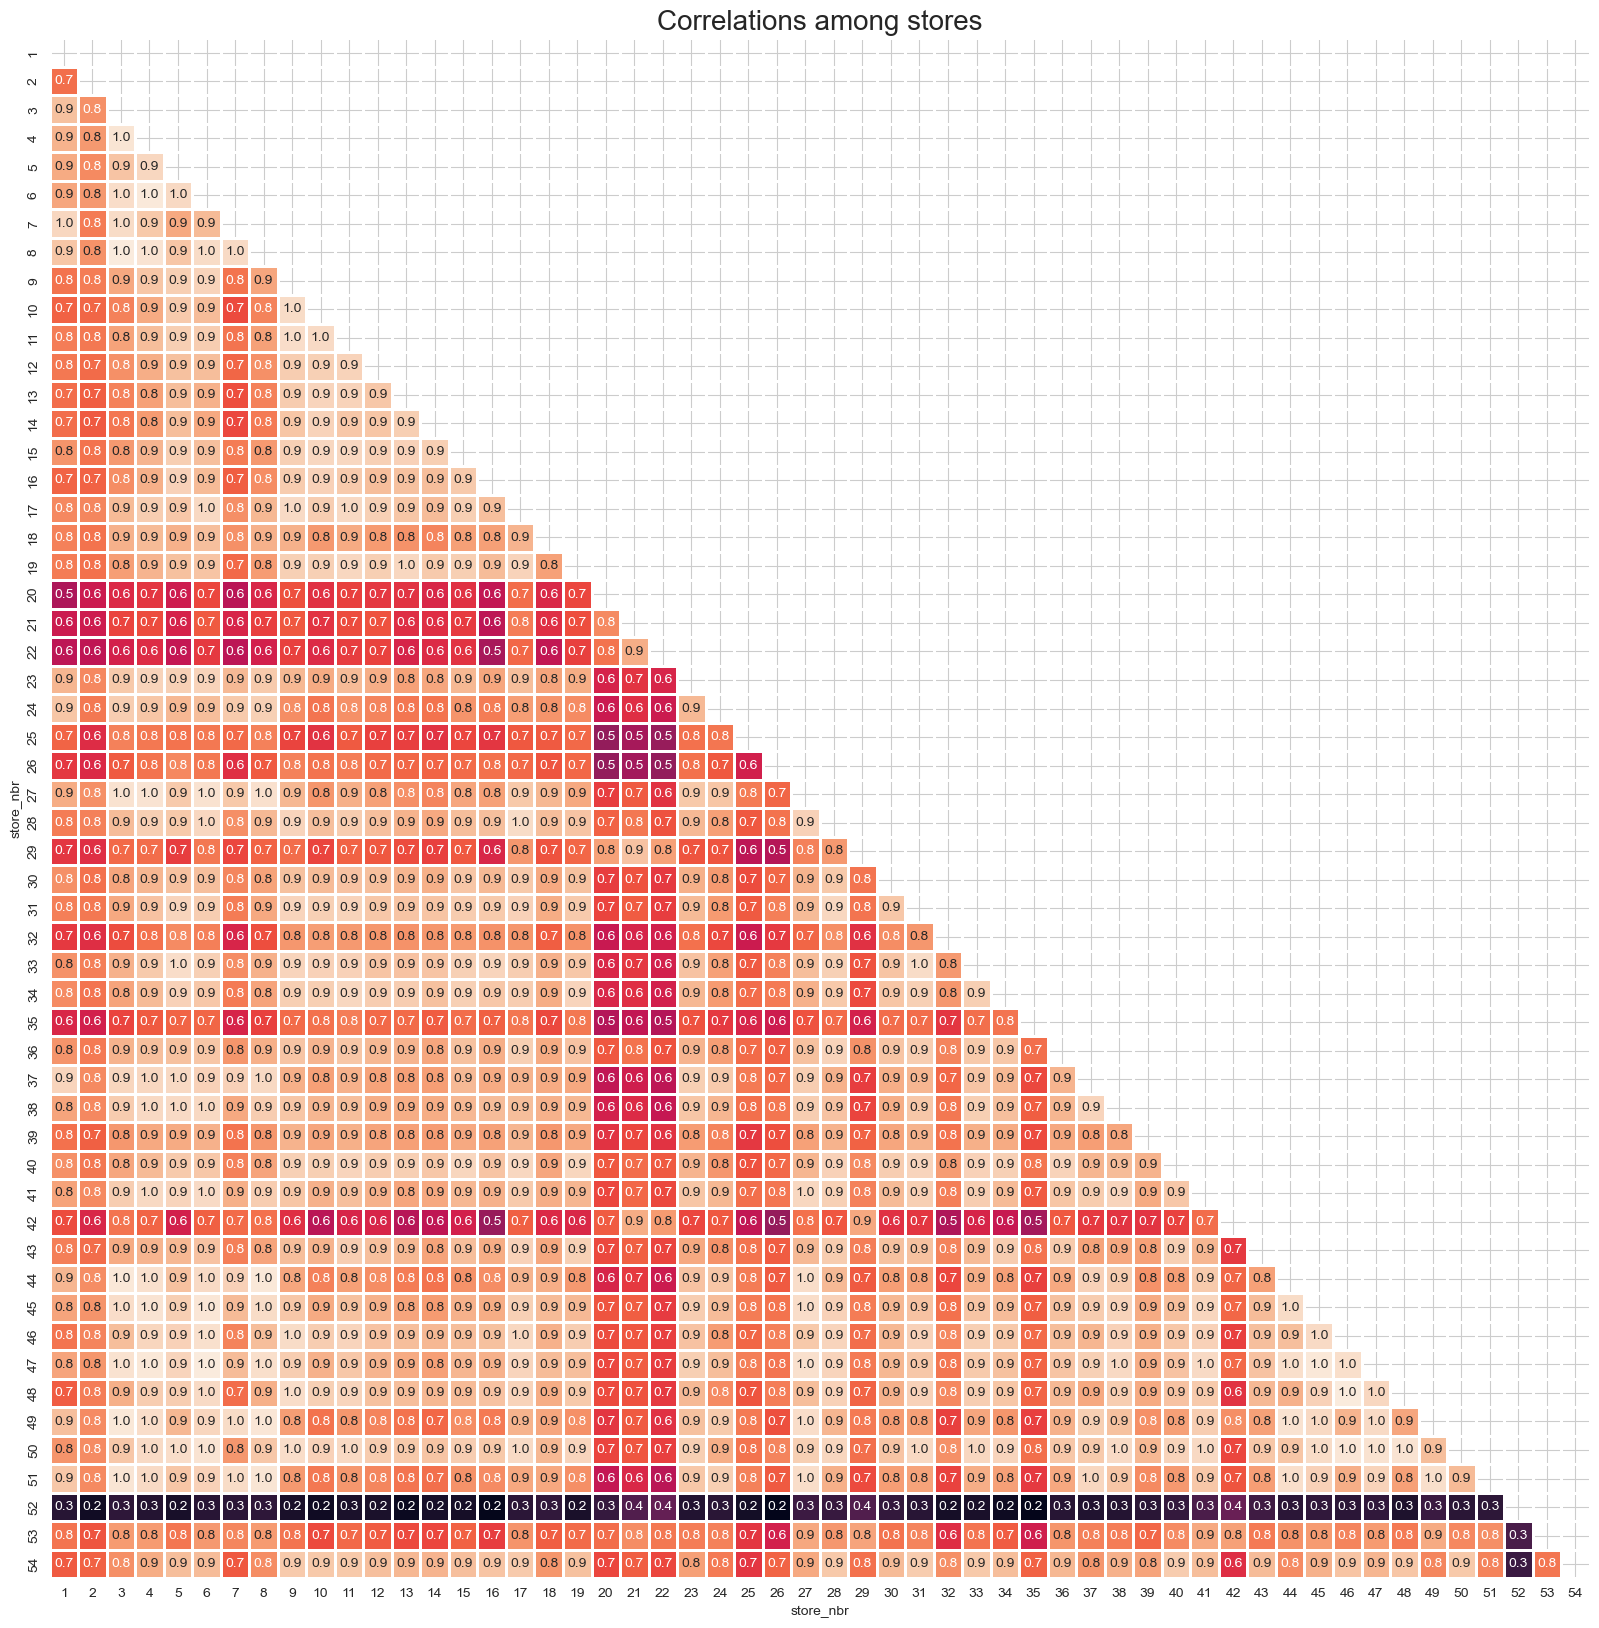

In [24]:
# Tương quan giữa các cửa hàng
a = train_data[["store_nbr", "sales"]] 
a["ind"] = 1 
a["ind"] = a.groupby("store_nbr").ind.cumsum().values 

a = pd.pivot(a, index = "ind", columns = "store_nbr", values = "sales").corr() 

mask = np.triu(a.corr()) 

plt.figure(figsize=(20, 20))
sns.heatmap(a,
         annot=True,
         fmt='.1f',
         square=True,
         mask=mask,
         linewidths=1,
         cbar=False)
plt.title("Correlations among stores",fontsize = 20)
plt.show()

# 3. Holiday Event Data

In [25]:
holiday_data = holiday_data.set_index('date')
holiday_data.head(5)

,type,locale,locale_name,description,transferred
date,,,,,
2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [26]:
print(holiday_data.info())
print("=="*30)
print(holiday_data.describe())
print("=="*30)
print(f"typr Unique: {len(holiday_data['type'].unique())}")
print(f"locale Unique: {len(holiday_data['locale'].unique())}")
print(f"locale_name Unique: {len(holiday_data['locale_name'].unique())}")
print("=="*30)
print(f"Missing Value: \n{holiday_data.isna().sum()}")

<class 'pandas.core.frame.DataFrame'>
Index: 350 entries, 2012-03-02 to 2017-12-26
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   type         350 non-null    object
 1   locale       350 non-null    object
 2   locale_name  350 non-null    object
 3   description  350 non-null    object
 4   transferred  350 non-null    bool  
dtypes: bool(1), object(4)
memory usage: 14.0+ KB
None
           type    locale locale_name description transferred
count       350       350         350         350         350
unique        6         3          24         103           2
top     Holiday  National     Ecuador    Carnaval       False
freq        221       174         174          10         338
typr Unique: 6
locale Unique: 3
locale_name Unique: 24
Missing Value: 
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64


In [27]:
holiday_data['type'].value_counts()

type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

In [28]:
# New Year Day
ny_dic = {'type': 'Holiday','locale':'National','locale_name':'Ecuador','description': 'New Year Day','transferred':'False'}
ny_date = pd.to_datetime(['2012-01-01','2013-01-01','2014-01-01','2015-01-01','2016-01-01','2017-01-01','2018-01-01'])
# Christmas Day
cm_dic = {'type': 'Holiday','locale':'National','locale_name':'Ecuador','description': 'Christmas Day','transferred':'False'}
cm_date = pd.to_datetime(['2012-12-25','2013-12-25','2014-12-25','2015-12-25','2016-12-25','2017-12-25','2018-12-25'])

holiday_data.index = pd.to_datetime(holiday_data.index)

for date in ny_date:
    holiday_data.loc[date] = [
        'Holiday','National','Ecuador',
        'New Year Day','False'
    ]

for date in cm_date:
    holiday_data.loc[date] = [
        'Holiday','National','Ecuador',
        'Christmas Day','False'
    ]

holiday_data = holiday_data.sort_index()
holiday_data.head(5)

,type,locale,locale_name,description,transferred
date,,,,,
2012-01-01,Holiday,National,Ecuador,New Year Day,False
2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False


In [29]:
# Tạo bộ dữ liệu mới để gộp với sale
calendar = pd.DataFrame(index = pd.date_range('2013-01-01','2017-08-31'))
calendar = calendar.join(holiday_data).fillna(0)

In [30]:
calendar['dow'] = calendar.index.dayofweek+1
calendar['workday'] = True
calendar.loc[calendar['dow'] > 5 , 'workday'] = False #make work_day false for sat and sun (6/7 in dow)
calendar.head(6)


,type,locale,locale_name,description,transferred,dow,workday
2013-01-01,Holiday,National,Ecuador,New Year Day,False,2,True
2013-01-02,0,0,0,0,0,3,True
2013-01-03,0,0,0,0,0,4,True
2013-01-04,0,0,0,0,0,5,True
2013-01-05,Work Day,National,Ecuador,Recupero puente Navidad,False,6,False
2013-01-06,0,0,0,0,0,7,False


In [31]:
calendar.loc[(calendar['type']=='Holiday') & (calendar['locale'].str.contains('National')), 'workday'] = False
calendar.loc[(calendar['type']=='Additional') & (calendar['locale'].str.contains('National')), 'workday'] = False
calendar.loc[(calendar['type']=='Bridge') & (calendar['locale'].str.contains('National')), 'workday'] = False
calendar.loc[(calendar['type']=='Transfer') & (calendar['locale'].str.contains('National')), 'workday'] = False

#some holiday are explicitly said it is workday
calendar.loc[calendar['type']=='Work Day' , 'workday'] = True


In [32]:
calendar.where(calendar['transferred'] == True).dropna()


,type,locale,locale_name,description,transferred,dow,workday
2013-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True,3.0,False
2014-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True,4.0,False
2016-05-24,Holiday,National,Ecuador,Batalla de Pichincha,True,2.0,False
2016-07-25,Holiday,Local,Guayaquil,Fundacion de Guayaquil,True,1.0,True
2016-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,True,3.0,False
2017-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,True,3.0,True
2017-05-24,Holiday,National,Ecuador,Batalla de Pichincha,True,3.0,False
2017-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,True,4.0,False


In [33]:
calendar.loc[(calendar['transferred'] == True), 'workday'] = True


In [34]:
calendar.where(calendar['description'].str.contains('futbol')).dropna()

,type,locale,locale_name,description,transferred,dow,workday
2014-06-12,Event,National,Ecuador,Inauguracion Mundial de futbol Brasil,False,4.0,True
2014-06-15,Event,National,Ecuador,Mundial de futbol Brasil: Ecuador-Suiza,False,7.0,False
2014-06-20,Event,National,Ecuador,Mundial de futbol Brasil: Ecuador-Honduras,False,5.0,True
2014-06-25,Event,National,Ecuador,Mundial de futbol Brasil: Ecuador-Francia,False,3.0,True
2014-06-28,Event,National,Ecuador,Mundial de futbol Brasil: Octavos de Final,False,6.0,False
2014-06-29,Event,National,Ecuador,Mundial de futbol Brasil: Octavos de Final,False,7.0,False
2014-06-30,Event,National,Ecuador,Mundial de futbol Brasil: Octavos de Final,False,1.0,True
2014-07-01,Event,National,Ecuador,Mundial de futbol Brasil: Octavos de Final,False,2.0,True
2014-07-04,Event,National,Ecuador,Mundial de futbol Brasil: Cuartos de Final,False,5.0,True
2014-07-05,Event,National,Ecuador,Mundial de futbol Brasil: Cuartos de Final,False,6.0,False


In [35]:
calendar['is_football'] = 0
calendar['is_eq'] = 0

calendar.loc[(calendar['is_football'] == 0) & (calendar['description'].str.contains('futbol')), 'is_football'] = 1
calendar.loc[(calendar['is_eq'] == 0) & (calendar['description'].str.contains('Terremoto')), 'is_eq'] = 1

In [36]:
calendar.where(calendar['is_football']==1).dropna().head()

,type,locale,locale_name,description,transferred,dow,workday,is_football,is_eq
2014-06-12,Event,National,Ecuador,Inauguracion Mundial de futbol Brasil,False,4.0,True,1.0,0.0
2014-06-15,Event,National,Ecuador,Mundial de futbol Brasil: Ecuador-Suiza,False,7.0,False,1.0,0.0
2014-06-20,Event,National,Ecuador,Mundial de futbol Brasil: Ecuador-Honduras,False,5.0,True,1.0,0.0
2014-06-25,Event,National,Ecuador,Mundial de futbol Brasil: Ecuador-Francia,False,3.0,True,1.0,0.0
2014-06-28,Event,National,Ecuador,Mundial de futbol Brasil: Octavos de Final,False,6.0,False,1.0,0.0


In [37]:
calendar.where(calendar['is_eq']==1).dropna().head()

,type,locale,locale_name,description,transferred,dow,workday,is_football,is_eq
2016-04-16,Event,National,Ecuador,Terremoto Manabi,False,6.0,False,0.0,1.0
2016-04-17,Event,National,Ecuador,Terremoto Manabi+1,False,7.0,False,0.0,1.0
2016-04-18,Event,National,Ecuador,Terremoto Manabi+2,False,1.0,True,0.0,1.0
2016-04-19,Event,National,Ecuador,Terremoto Manabi+3,False,2.0,True,0.0,1.0
2016-04-20,Event,National,Ecuador,Terremoto Manabi+4,False,3.0,True,0.0,1.0


In [38]:
calendar.loc[calendar['is_football']==1,'description'] = 'football'
calendar.loc[calendar['is_eq']==1,'description'] = 'earthquake'

In [39]:
calendar.head(5)

,type,locale,locale_name,description,transferred,dow,workday,is_football,is_eq
2013-01-01,Holiday,National,Ecuador,New Year Day,False,2,False,0,0
2013-01-02,0,0,0,0,0,3,True,0,0
2013-01-03,0,0,0,0,0,4,True,0,0
2013-01-04,0,0,0,0,0,5,True,0,0
2013-01-05,Work Day,National,Ecuador,Recupero puente Navidad,False,6,True,0,0


In [40]:
sales = train_data.groupby('date').sales.sum()
event = calendar[calendar['type']=='Event']

event_merge = event.merge(sales,how='left',left_index=True,right_index=True)
event_merge.head(5)

,type,locale,locale_name,description,transferred,dow,workday,is_football,is_eq,sales
2013-05-12,Event,National,Ecuador,Dia de la Madre,False,7,False,0,0,387860.505014
2014-05-11,Event,National,Ecuador,Dia de la Madre,False,7,False,0,0,454512.928937
2014-06-12,Event,National,Ecuador,football,False,4,True,1,0,329408.067360
2014-06-15,Event,National,Ecuador,football,False,7,False,1,0,441279.933995
2014-06-20,Event,National,Ecuador,football,False,5,True,1,0,369206.789547


In [41]:
print('mean of daily sale across country: {}'.format(train_data.groupby('date').sales.sum().mean()))
print('--------------------')
print(('mean of sale across country in event day: {}'.format(event_merge.groupby('description').sales.mean())))

mean of daily sale across country: 637556.3849186868
--------------------
mean of sale across country in event day: description
Black Friday       647508.781658
Cyber Monday       777344.484674
Dia de la Madre    621092.051781
earthquake         881919.056300
football           554139.887353
Name: sales, dtype: float64


# 4. Oil.csv

In [42]:
oil_data.head(4)


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12


In [43]:
pd.date_range(start = '2013-01-01', end = '2017-08-15' ).difference(oil_data.index)


DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2017-08-06', '2017-08-07', '2017-08-08', '2017-08-09',
               '2017-08-10', '2017-08-11', '2017-08-12', '2017-08-13',
               '2017-08-14', '2017-08-15'],
              dtype='datetime64[ns]', length=1688, freq='D')

In [44]:
oil_data['date'] = pd.to_datetime(oil_data['date'])
oil_data = oil_data.set_index('date')
oil_data = oil_data.resample('1D').sum()
oil_data.reset_index()


,date,dcoilwtico
0,2013-01-01,0.00
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-05,0.00
...,...,...
1699,2017-08-27,0.00
1700,2017-08-28,46.40
1701,2017-08-29,46.46
1702,2017-08-30,45.96


In [45]:
oil_data['dcoilwtico'] = np.where(oil_data['dcoilwtico']==0, np.nan, oil_data['dcoilwtico'])
oil_data['interpolated_price'] = oil_data.dcoilwtico.interpolate()

oil_data = oil_data.drop('dcoilwtico',axis=1)

oil_data.head()


,interpolated_price
date,
2013-01-01,NaN
2013-01-02,93.140000
2013-01-03,92.970000
2013-01-04,93.120000
2013-01-05,93.146667


In [46]:
oil_data['price_chg'] = oil_data.interpolated_price - oil_data.interpolated_price.shift(1)
oil_data['pct_chg'] = oil_data['price_chg']/oil_data.interpolated_price.shift(-1)
oil_data.head()


,interpolated_price,price_chg,pct_chg
date,,,
2013-01-01,NaN,NaN,NaN
2013-01-02,93.140000,NaN,NaN
2013-01-03,92.970000,-0.170000,-0.001826
2013-01-04,93.120000,0.150000,0.001610
2013-01-05,93.146667,0.026667,0.000286


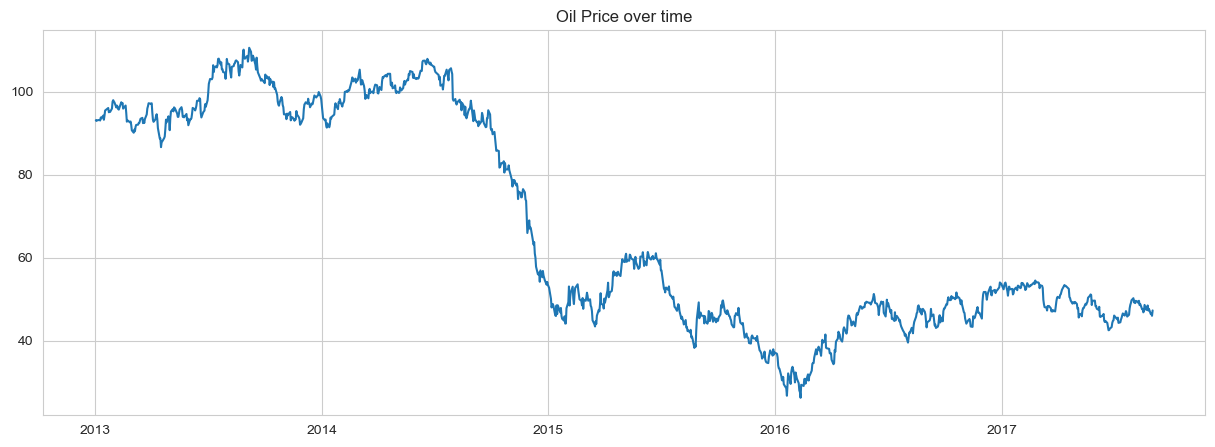

In [47]:
fig,ax = plt.subplots(figsize=(15,5))
plt.plot(oil_data['interpolated_price'])
plt.title('Oil Price over time')
plt.show()


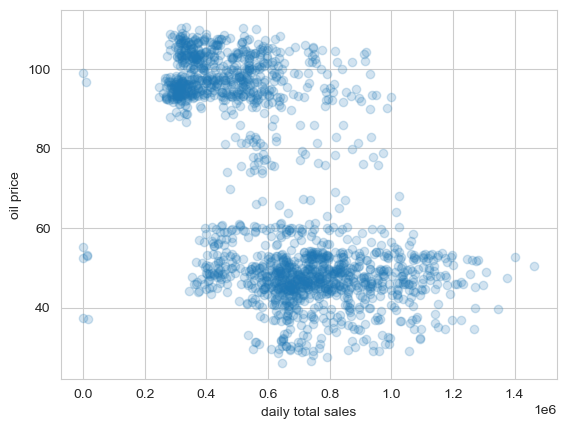

In [48]:
daily_total_sales = total_sales.copy()
daily_total_sales = daily_total_sales.resample('1D').sum()

plt.scatter(daily_total_sales,oil_data.interpolated_price.loc['2013-01-01':'2017-08-15'],alpha=0.2)
plt.ylabel('oil price')
plt.xlabel('daily total sales')
plt.show()

# 5. Transactions.csv

In [49]:
transactions = transaction_data.copy()
transactions = transactions.set_index('date')
transactions.index = pd.to_datetime(transactions.index)
transactions.head()

,store_nbr,transactions
date,,
2013-01-01,25,770
2013-01-02,1,2111
2013-01-02,2,2358
2013-01-02,3,3487
2013-01-02,4,1922


In [50]:
# Giao dịch của từng cửa hàng
def transaction_sales_dic(transaction_df,sale_dic):
    transaction_dic = {}
    sale_dict = sale_dic.copy()

    for i in transaction_df['store_nbr'].unique():
        store_transacion = transaction_df.loc[transaction_df['store_nbr'] == i]
        transaction_dic[i] = store_transacion['transactions']
        
    for i in sale_dict.keys():
        sale_dict[i] = sale_dict[i].groupby(['date','store_nbr']).sales.sum()
        sale_dict[i] = sale_dict[i].reset_index()
        sale_dict[i] = sale_dict[i].drop('store_nbr', axis=1)
        sale_dict[i] = sale_dict[i].groupby('date').sales.sum()
            
    return transaction_dic, sale_dict
        
def  series_merge_inner_index(dic1, dic2):
    merged_dic = {}
    for key in dic1.keys():
        merged_dic[key] = dic1[key].to_frame().merge(dic2[key].to_frame(), how='inner',
                                                    left_index=True, right_index=True)
    return merged_dic

In [51]:
transaction_dic, sale_dic = transaction_sales_dic(transactions,daily_sale_dict)
merged_sales_transaction = series_merge_inner_index(transaction_dic, sale_dic)
merged_sales_transaction[1]

,transactions,sales
date,,
2013-01-02,2111,7417.148000
2013-01-03,1833,5873.244001
2013-01-04,1863,5919.879001
2013-01-05,1509,6318.785010
2013-01-06,520,2199.087000
...,...,...
2017-08-11,570,5403.742021
2017-08-12,1004,7543.623000
2017-08-13,416,3902.782000


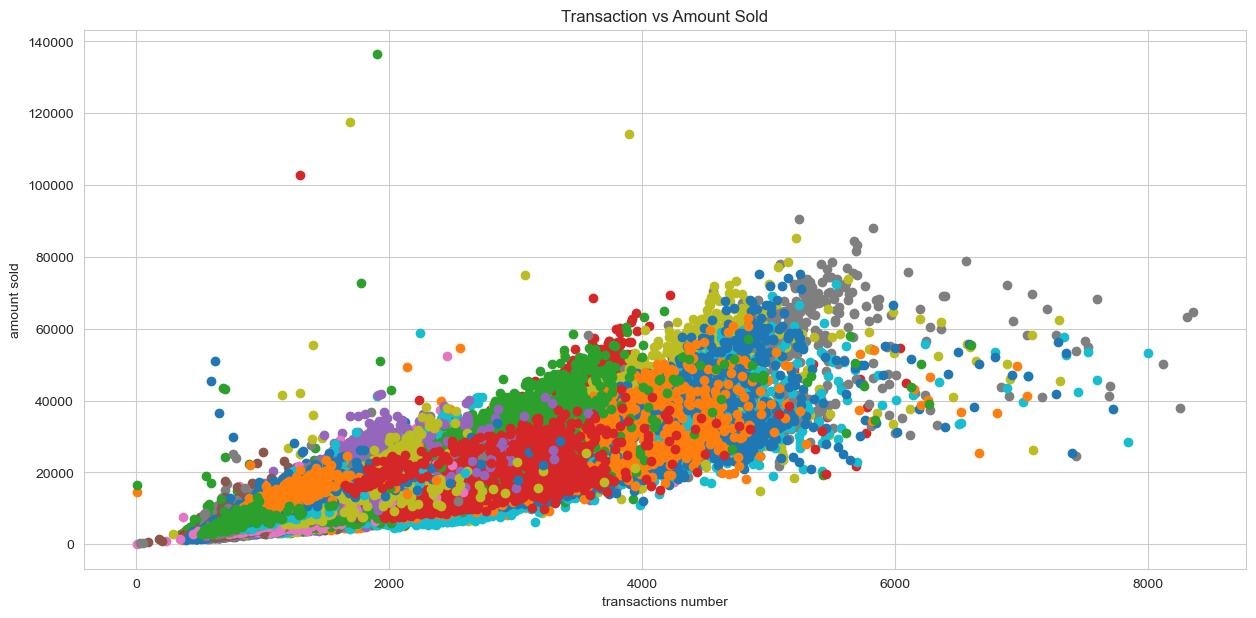

In [52]:
fig, ax = plt.subplots(figsize=(15,7))
for key in merged_sales_transaction.keys():
    plt.scatter(merged_sales_transaction[key].transactions,
                merged_sales_transaction[key].sales)

plt.title('Transaction vs Amount Sold')
plt.xlabel('transactions number')
plt.ylabel('amount sold')
plt.show()

# 5. Feature Engineering

In [53]:
calendar['workday'] = calendar['workday'].map({False:0,True:1})
calendar['transferred'] = calendar['transferred'].map({'False':0,False:0,True:1})

calendar['is_ny'] = 0
calendar['is_christmas'] = 0
calendar['is_shopping'] = 0

calendar.loc[calendar['description'] == 'New Year day', 'is_ny'] = 1
calendar.loc[calendar['description'] == 'Christmas day', 'is_christmas'] = 1
calendar.loc[calendar['description'] == 'Black Friday', 'is_shopping'] = 1
calendar.loc[calendar['description'] == 'Cyber Monday' , 'is_shopping'] = 1

calendar = calendar.drop(['type','locale'], axis=1)

calendar.head()

,locale_name,description,transferred,dow,workday,is_football,is_eq,is_ny,is_christmas,is_shopping
2013-01-01,Ecuador,New Year Day,0,2,0,0,0,0,0,0
2013-01-02,0,0,0,3,1,0,0,0,0,0
2013-01-03,0,0,0,4,1,0,0,0,0,0
2013-01-04,0,0,0,5,1,0,0,0,0,0
2013-01-05,Ecuador,Recupero puente Navidad,0,6,1,0,0,0,0,0


In [54]:
locale_dummy = pd.get_dummies(calendar['locale_name'],prefix='holiday_').astype(int)
calendar = locale_dummy.join(calendar,how='left')
calendar = calendar.drop('locale_name',axis=1)

In [55]:
calendar_checkpoint = calendar

In [56]:
calendar_checkpoint = calendar_checkpoint.drop('description',axis = 1) 
calendar_checkpoint = calendar_checkpoint[~calendar_checkpoint.index.duplicated(keep='first')] 
calendar_checkpoint = calendar_checkpoint.iloc[:,1:-1]

In [57]:
calendar_checkpoint.head()

,holiday__Ambato,holiday__Cayambe,holiday__Cotopaxi,holiday__Cuenca,holiday__Ecuador,holiday__El Carmen,holiday__Esmeraldas,holiday__Guaranda,holiday__Guayaquil,holiday__Ibarra,...,holiday__Santa Elena,holiday__Santo Domingo,holiday__Santo Domingo de los Tsachilas,transferred,dow,workday,is_football,is_eq,is_ny,is_christmas
2013-01-01,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2013-01-02,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,3,1,0,0,0,0
2013-01-03,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,4,1,0,0,0,0
2013-01-04,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,5,1,0,0,0,0
2013-01-05,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,6,1,0,0,0,0


In [58]:
train_data['id'] = train_data.reset_index().index
train_data = train_data.reset_index()
train_data = train_data[['id','date','store_nbr','family','sales','onpromotion']]
train_data.head(5)

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [59]:
merged_train = train_data.copy()
merged_train = merged_train.set_index(['date','store_nbr','family'])
merged_train

id     sales  \
date       store_nbr family                                          
2013-01-01 1         AUTOMOTIVE                        0     0.000   
                     BABY CARE                         1     0.000   
                     BEAUTY                            2     0.000   
                     BEVERAGES                         3     0.000   
                     BOOKS                             4     0.000   
...                                                  ...       ...   
2017-08-15 9         POULTRY                     3000883   438.133   
                     PREPARED FOODS              3000884   154.553   
                     PRODUCE                     3000885  2419.729   
                     SCHOOL AND OFFICE SUPPLIES  3000886   121.000   
                     SEAFOOD                     3000887    16.000   

                                                 onpromotion  
date       store_nbr family                                   
2013-01-01 1         AUTOMOTIVE                            0  
                     BABY CARE                             0  
                     BEAUTY                                0  
                     BEVERAGES                             0  
                     BOOKS                                 0  
...                                                      ...  
2017-08-15 9         POULTRY                               0  
                     PREPARED FOODS                        1  
                     PRODUCE                             148  
                     SCHOOL AND OFFICE SUPPLIES            8  
                     SEAFOOD                               0  

[3000888 rows x 3 columns]

In [60]:
store_location = stores_data.drop(['state','type','cluster'],axis=1) 
store_location = store_location.set_index('store_nbr')
store_location = pd.get_dummies(store_location, prefix='store_loc_').astype(int)

In [61]:
store_location.head(5)

,store_loc__Ambato,store_loc__Babahoyo,store_loc__Cayambe,store_loc__Cuenca,store_loc__Daule,store_loc__El Carmen,store_loc__Esmeraldas,store_loc__Guaranda,store_loc__Guayaquil,store_loc__Ibarra,...,store_loc__Loja,store_loc__Machala,store_loc__Manta,store_loc__Playas,store_loc__Puyo,store_loc__Quevedo,store_loc__Quito,store_loc__Riobamba,store_loc__Salinas,store_loc__Santo Domingo
store_nbr,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [62]:
inputs = merged_train.reset_index().merge(store_location,how='outer',left_on='store_nbr',right_on=store_location.index)

In [63]:
total_sales_to_scale = pd.DataFrame(index=pd.date_range(start='2013-01-01',end='2017-08-31'))
total_sales_to_scale = total_sales_to_scale.merge(total_sales,how='left',left_index=True,right_index=True)
total_sales_to_scale = total_sales_to_scale.rename(columns={'sales':'national_sales'})

In [64]:
total_sales_to_scale

,national_sales
2013-01-01,2511.618999
2013-01-02,496092.417944
2013-01-03,361461.231124
2013-01-04,354459.677093
2013-01-05,477350.121229
...,...
2017-08-27,NaN
2017-08-28,NaN
2017-08-29,NaN
2017-08-30,NaN


In [65]:
mmScale = MinMaxScaler()
mmScale.fit(total_sales_to_scale['national_sales'].to_numpy().reshape(-1,1))

total_sales_to_scale['scaled_nat_sales'] = mmScale.transform(total_sales_to_scale['national_sales'].to_numpy().reshape(-1,1))

In [66]:
total_sales_to_scale

,national_sales,scaled_nat_sales
2013-01-01,2511.618999,0.000000
2013-01-02,496092.417944,0.337937
2013-01-03,361461.231124,0.245760
2013-01-04,354459.677093,0.240966
2013-01-05,477350.121229,0.325104
...,...,...
2017-08-27,NaN,NaN
2017-08-28,NaN,NaN
2017-08-29,NaN,NaN
2017-08-30,NaN,NaN


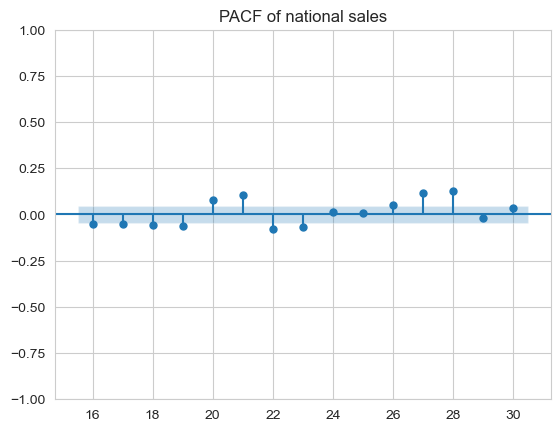

In [67]:
import  statsmodels.graphics.tsaplots # for partial autocorrelation

ax = statsmodels.graphics.tsaplots.plot_pacf(total_sales_to_scale['scaled_nat_sales'].dropna(), 
                                                 lags=range(16,31),
                                                 title = 'PACF of national sales')

In [68]:
lags= [16,17,18,19,20,21,22,23,24,27,28]
for lag in lags:
    total_sales_to_scale['nat_scaled_sales_lag{}'.format(lag)] = total_sales_to_scale['scaled_nat_sales'].shift(lag)

In [69]:
total_sales_to_scale = total_sales_to_scale.drop(['national_sales','scaled_nat_sales'],axis=1)

In [70]:
total_sales_to_scale.reset_index().tail()

,index,nat_scaled_sales_lag16,nat_scaled_sales_lag17,nat_scaled_sales_lag18,nat_scaled_sales_lag19,nat_scaled_sales_lag20,nat_scaled_sales_lag21,nat_scaled_sales_lag22,nat_scaled_sales_lag23,nat_scaled_sales_lag24,nat_scaled_sales_lag27,nat_scaled_sales_lag28
1699,2017-08-27,0.564068,0.444261,0.500919,0.489709,0.544275,0.716875,0.659455,0.565028,0.496762,0.604794,0.767672
1700,2017-08-28,0.540965,0.564068,0.444261,0.500919,0.489709,0.544275,0.716875,0.659455,0.565028,0.675089,0.604794
1701,2017-08-29,0.590952,0.540965,0.564068,0.444261,0.500919,0.489709,0.544275,0.716875,0.659455,0.658783,0.675089
1702,2017-08-30,0.519256,0.590952,0.540965,0.564068,0.444261,0.500919,0.489709,0.544275,0.716875,0.496762,0.658783
1703,2017-08-31,0.520447,0.519256,0.590952,0.540965,0.564068,0.444261,0.500919,0.489709,0.544275,0.565028,0.496762


In [71]:
# Convert the 'date' column in your left dataframe to datetime
inputs['date'] = pd.to_datetime(inputs['date'])

# Now run your merge again
inputs = inputs.merge(
    total_sales_to_scale.reset_index(),
    how='left',
    left_on='date',
    right_on='index'
)

In [72]:
inputs.columns

Index(['date', 'store_nbr', 'family', 'id', 'sales', 'onpromotion',
       'store_loc__Ambato', 'store_loc__Babahoyo', 'store_loc__Cayambe',
       'store_loc__Cuenca', 'store_loc__Daule', 'store_loc__El Carmen',
       'store_loc__Esmeraldas', 'store_loc__Guaranda', 'store_loc__Guayaquil',
       'store_loc__Ibarra', 'store_loc__Latacunga', 'store_loc__Libertad',
       'store_loc__Loja', 'store_loc__Machala', 'store_loc__Manta',
       'store_loc__Playas', 'store_loc__Puyo', 'store_loc__Quevedo',
       'store_loc__Quito', 'store_loc__Riobamba', 'store_loc__Salinas',
       'store_loc__Santo Domingo', 'index', 'nat_scaled_sales_lag16',
       'nat_scaled_sales_lag17', 'nat_scaled_sales_lag18',
       'nat_scaled_sales_lag19', 'nat_scaled_sales_lag20',
       'nat_scaled_sales_lag21', 'nat_scaled_sales_lag22',
       'nat_scaled_sales_lag23', 'nat_scaled_sales_lag24',
       'nat_scaled_sales_lag27', 'nat_scaled_sales_lag28'],
      dtype='object')

In [73]:
inputs.drop(['index'],axis=1,inplace=True)

In [74]:
lags = [1,2,3,4,5,6,7,8,13,14]

for lag in lags:
    inputs[f'store_fam_sales_lag_{lag}'] = (
        inputs.groupby(['store_nbr','family'])['sales']
        .shift(lag)
    )

In [75]:
inputs.columns

Index(['date', 'store_nbr', 'family', 'id', 'sales', 'onpromotion',
       'store_loc__Ambato', 'store_loc__Babahoyo', 'store_loc__Cayambe',
       'store_loc__Cuenca', 'store_loc__Daule', 'store_loc__El Carmen',
       'store_loc__Esmeraldas', 'store_loc__Guaranda', 'store_loc__Guayaquil',
       'store_loc__Ibarra', 'store_loc__Latacunga', 'store_loc__Libertad',
       'store_loc__Loja', 'store_loc__Machala', 'store_loc__Manta',
       'store_loc__Playas', 'store_loc__Puyo', 'store_loc__Quevedo',
       'store_loc__Quito', 'store_loc__Riobamba', 'store_loc__Salinas',
       'store_loc__Santo Domingo', 'nat_scaled_sales_lag16',
       'nat_scaled_sales_lag17', 'nat_scaled_sales_lag18',
       'nat_scaled_sales_lag19', 'nat_scaled_sales_lag20',
       'nat_scaled_sales_lag21', 'nat_scaled_sales_lag22',
       'nat_scaled_sales_lag23', 'nat_scaled_sales_lag24',
       'nat_scaled_sales_lag27', 'nat_scaled_sales_lag28',
       'store_fam_sales_lag_1', 'store_fam_sales_lag_2',
       'sto

In [76]:
store_nbr = range(1,55)
dates = pd.date_range('2013-01-01','2017-08-31')
mul_index = pd.MultiIndex.from_product([dates,store_nbr],names=['date','store_nbr'])
df = pd.DataFrame(index=mul_index)

In [77]:
df.reset_index()

,date,store_nbr
0,2013-01-01,1
1,2013-01-01,2
2,2013-01-01,3
3,2013-01-01,4
4,2013-01-01,5
...,...,...
92011,2017-08-31,50
92012,2017-08-31,51
92013,2017-08-31,52
92014,2017-08-31,53


In [78]:
df_transaction = df.reset_index().merge(transactions.reset_index(),
                                        how='left',
                                        left_on=['date','store_nbr'],
                                        right_on=['date','store_nbr']
                                       )

In [79]:
df_transaction.fillna(0, inplace=True)

In [80]:
lags = [21,22,28]
for lag in lags:
    df_transaction[f'trans_lag_{lag}'] = (
    df_transaction.groupby('store_nbr')['transactions']
    .shift(lag))
df_transaction = df_transaction.drop('transactions',axis=1)

df_transaction = df_transaction.fillna(0)

df_transaction.loc[30030:30040]

,date,store_nbr,trans_lag_21,trans_lag_22,trans_lag_28
30030,2014-07-11,7,2033.0,1689.0,2127.0
30031,2014-07-11,8,2715.0,2608.0,2961.0
30032,2014-07-11,9,1723.0,1844.0,1828.0
30033,2014-07-11,10,870.0,945.0,921.0
30034,2014-07-11,11,2222.0,2122.0,2045.0
30035,2014-07-11,12,1145.0,1186.0,1097.0
30036,2014-07-11,13,840.0,842.0,852.0
30037,2014-07-11,14,1256.0,1355.0,1223.0
30038,2014-07-11,15,1332.0,1346.0,1218.0
30039,2014-07-11,16,887.0,817.0,781.0


In [81]:
inputs = inputs.merge(df_transaction, how='left', left_on = ['date','store_nbr'],right_on = ['date','store_nbr'])

In [82]:
inputs = inputs.merge(calendar_checkpoint,how='left',left_on=['date'],right_on=calendar_checkpoint.index)

In [83]:
inputs.columns

Index(['date', 'store_nbr', 'family', 'id', 'sales', 'onpromotion',
       'store_loc__Ambato', 'store_loc__Babahoyo', 'store_loc__Cayambe',
       'store_loc__Cuenca', 'store_loc__Daule', 'store_loc__El Carmen',
       'store_loc__Esmeraldas', 'store_loc__Guaranda', 'store_loc__Guayaquil',
       'store_loc__Ibarra', 'store_loc__Latacunga', 'store_loc__Libertad',
       'store_loc__Loja', 'store_loc__Machala', 'store_loc__Manta',
       'store_loc__Playas', 'store_loc__Puyo', 'store_loc__Quevedo',
       'store_loc__Quito', 'store_loc__Riobamba', 'store_loc__Salinas',
       'store_loc__Santo Domingo', 'nat_scaled_sales_lag16',
       'nat_scaled_sales_lag17', 'nat_scaled_sales_lag18',
       'nat_scaled_sales_lag19', 'nat_scaled_sales_lag20',
       'nat_scaled_sales_lag21', 'nat_scaled_sales_lag22',
       'nat_scaled_sales_lag23', 'nat_scaled_sales_lag24',
       'nat_scaled_sales_lag27', 'nat_scaled_sales_lag28',
       'store_fam_sales_lag_1', 'store_fam_sales_lag_2',
       'sto

In [84]:
inputs = inputs.set_index('date')

In [85]:
inputs.tail(5)

,store_nbr,family,id,sales,onpromotion,store_loc__Ambato,store_loc__Babahoyo,store_loc__Cayambe,store_loc__Cuenca,store_loc__Daule,...,holiday__Santa Elena,holiday__Santo Domingo,holiday__Santo Domingo de los Tsachilas,transferred,dow,workday,is_football,is_eq,is_ny,is_christmas
date,,,,,,,,,,,,,,,,,,,,,
2017-08-15,54,POULTRY,3000751,59.619,0,0,0,0,0,0,...,0,0,0,0,2,1,0,0,0,0
2017-08-15,54,PREPARED FOODS,3000752,94.000,0,0,0,0,0,0,...,0,0,0,0,2,1,0,0,0,0
2017-08-15,54,PRODUCE,3000753,915.371,76,0,0,0,0,0,...,0,0,0,0,2,1,0,0,0,0
2017-08-15,54,SCHOOL AND OFFICE SUPPLIES,3000754,0.000,0,0,0,0,0,0,...,0,0,0,0,2,1,0,0,0,0
2017-08-15,54,SEAFOOD,3000755,3.000,0,0,0,0,0,0,...,0,0,0,0,2,1,0,0,0,0


In [86]:
pd.set_option('display.max_rows',None)
inputs.isna().sum()

store_nbr                                      0
family                                         0
id                                             0
sales                                          0
onpromotion                                    0
store_loc__Ambato                              0
store_loc__Babahoyo                            0
store_loc__Cayambe                             0
store_loc__Cuenca                              0
store_loc__Daule                               0
store_loc__El Carmen                           0
store_loc__Esmeraldas                          0
store_loc__Guaranda                            0
store_loc__Guayaquil                           0
store_loc__Ibarra                              0
store_loc__Latacunga                           0
store_loc__Libertad                            0
store_loc__Loja                                0
store_loc__Machala                             0
store_loc__Manta                               0
store_loc__Playas   

In [87]:
inputs.dropna(inplace = True)
inputs.isna().sum().sum()

np.int64(0)

In [88]:
inputs.tail(5)

,store_nbr,family,id,sales,onpromotion,store_loc__Ambato,store_loc__Babahoyo,store_loc__Cayambe,store_loc__Cuenca,store_loc__Daule,...,holiday__Santa Elena,holiday__Santo Domingo,holiday__Santo Domingo de los Tsachilas,transferred,dow,workday,is_football,is_eq,is_ny,is_christmas
date,,,,,,,,,,,,,,,,,,,,,
2017-08-15,54,POULTRY,3000751,59.619,0,0,0,0,0,0,...,0,0,0,0,2,1,0,0,0,0
2017-08-15,54,PREPARED FOODS,3000752,94.000,0,0,0,0,0,0,...,0,0,0,0,2,1,0,0,0,0
2017-08-15,54,PRODUCE,3000753,915.371,76,0,0,0,0,0,...,0,0,0,0,2,1,0,0,0,0
2017-08-15,54,SCHOOL AND OFFICE SUPPLIES,3000754,0.000,0,0,0,0,0,0,...,0,0,0,0,2,1,0,0,0,0
2017-08-15,54,SEAFOOD,3000755,3.000,0,0,0,0,0,0,...,0,0,0,0,2,1,0,0,0,0


In [89]:
inputs.index = pd.to_datetime(inputs.index)
inputs = inputs.sort_index()

y_train = inputs.loc[:'2017-07-31', 'sales']
y_train.tail()

date
2017-07-31    1089.266
2017-07-31       0.000
2017-07-31       1.000
2017-07-31      14.352
2017-07-31      12.000
Name: sales, dtype: float64

In [90]:
x_train = inputs.loc['2013-01-01':'2017-07-31'].drop(['sales','id'],axis=1)
x_train = x_train.reset_index()
x_train = x_train.set_index(['date','store_nbr','family'])

In [91]:
x_train.tail()

onpromotion  \
date       store_nbr family                                    
2017-07-31 20        PRODUCE                               8   
           46        BABY CARE                             0   
           20        SCHOOL AND OFFICE SUPPLIES            1   
                     SEAFOOD                               0   
           46        AUTOMOTIVE                            0   

                                                 store_loc__Ambato  \
date       store_nbr family                                          
2017-07-31 20        PRODUCE                                     0   
           46        BABY CARE                                   0   
           20        SCHOOL AND OFFICE SUPPLIES                  0   
                     SEAFOOD                                     0   
           46        AUTOMOTIVE                                  0   

                                                 store_loc__Babahoyo  \
date       store_nbr family                                            
2017-07-31 20        PRODUCE                                       0   
           46        BABY CARE                                     0   
           20        SCHOOL AND OFFICE SUPPLIES                    0   
                     SEAFOOD                                       0   
           46        AUTOMOTIVE                                    0   

                                                 store_loc__Cayambe  \
date       store_nbr family                                           
2017-07-31 20        PRODUCE                                      0   
           46        BABY CARE                                    0   
           20        SCHOOL AND OFFICE SUPPLIES                   0   
                     SEAFOOD                                      0   
           46        AUTOMOTIVE                                   0   

                                                 store_loc__Cuenca  \
date       store_nbr family                                          
2017-07-31 20        PRODUCE                                     0   
           46        BABY CARE                                   0   
           20        SCHOOL AND OFFICE SUPPLIES                  0   
                     SEAFOOD                                     0   
           46        AUTOMOTIVE                                  0   

                                                 store_loc__Daule  \
date       store_nbr family                                         
2017-07-31 20        PRODUCE                                    0   
           46        BABY CARE                                  0   
           20        SCHOOL AND OFFICE SUPPLIES                 0   
                     SEAFOOD                                    0   
           46        AUTOMOTIVE                                 0   

                                                 store_loc__El Carmen  \
date       store_nbr family                                             
2017-07-31 20        PRODUCE                                        0   
           46        BABY CARE                                      0   
           20        SCHOOL AND OFFICE SUPPLIES                     0   
                     SEAFOOD                                        0   
           46        AUTOMOTIVE                                     0   

                                                 store_loc__Esmeraldas  \
date       store_nbr family                                              
2017-07-31 20        PRODUCE                                         0   
           46        BABY CARE                                       0   
           20        SCHOOL AND OFFICE SUPPLIES                      0   
                     SEAFOOD                                         0   
           46        AUTOMOTIVE                                      0   

                                                 store_loc__Guaranda  \
date       store_nbr family 

In [92]:
x_train.columns

Index(['onpromotion', 'store_loc__Ambato', 'store_loc__Babahoyo',
       'store_loc__Cayambe', 'store_loc__Cuenca', 'store_loc__Daule',
       'store_loc__El Carmen', 'store_loc__Esmeraldas', 'store_loc__Guaranda',
       'store_loc__Guayaquil', 'store_loc__Ibarra', 'store_loc__Latacunga',
       'store_loc__Libertad', 'store_loc__Loja', 'store_loc__Machala',
       'store_loc__Manta', 'store_loc__Playas', 'store_loc__Puyo',
       'store_loc__Quevedo', 'store_loc__Quito', 'store_loc__Riobamba',
       'store_loc__Salinas', 'store_loc__Santo Domingo',
       'nat_scaled_sales_lag16', 'nat_scaled_sales_lag17',
       'nat_scaled_sales_lag18', 'nat_scaled_sales_lag19',
       'nat_scaled_sales_lag20', 'nat_scaled_sales_lag21',
       'nat_scaled_sales_lag22', 'nat_scaled_sales_lag23',
       'nat_scaled_sales_lag24', 'nat_scaled_sales_lag27',
       'nat_scaled_sales_lag28', 'store_fam_sales_lag_1',
       'store_fam_sales_lag_2', 'store_fam_sales_lag_3',
       'store_fam_sales_lag_4', 

In [93]:
x_test = inputs.loc['2017-08-01':]
y_test = inputs.loc['2017-08-01':, 'sales']

x_test.drop(['sales','id'],axis = 1,inplace = True)

x_test = x_test.reset_index()
x_test = x_test.set_index(['date','store_nbr','family'])


C:\Users\THIEN\AppData\Local\Temp\ipykernel_25972\1501693605.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test.drop(['sales','id'],axis = 1,inplace = True)


In [94]:
x_test.head()

onpromotion  store_loc__Ambato  \
date       store_nbr family                                                    
2017-08-01 7         MEATS                              0                  0   
                     PERSONAL CARE                      5                  0   
                     PET SUPPLIES                       0                  0   
                     PLAYERS AND ELECTRONICS            0                  0   
           2         BABY CARE                          0                  0   

                                              store_loc__Babahoyo  \
date       store_nbr family                                         
2017-08-01 7         MEATS                                      0   
                     PERSONAL CARE                              0   
                     PET SUPPLIES                               0   
                     PLAYERS AND ELECTRONICS                    0   
           2         BABY CARE                                  0   

                                              store_loc__Cayambe  \
date       store_nbr family                                        
2017-08-01 7         MEATS                                     0   
                     PERSONAL CARE                             0   
                     PET SUPPLIES                              0   
                     PLAYERS AND ELECTRONICS                   0   
           2         BABY CARE                                 0   

                                              store_loc__Cuenca  \
date       store_nbr family                                       
2017-08-01 7         MEATS                                    0   
                     PERSONAL CARE                            0   
                     PET SUPPLIES                             0   
                     PLAYERS AND ELECTRONICS                  0   
           2         BABY CARE                                0   

                                              store_loc__Daule  \
date       store_nbr family                                      
2017-08-01 7         MEATS                                   0   
                     PERSONAL CARE                           0   
                     PET SUPPLIES                            0   
                     PLAYERS AND ELECTRONICS                 0   
           2         BABY CARE                               0   

                                              store_loc__El Carmen  \
date       store_nbr family                                          
2017-08-01 7         MEATS                                       0   
                     PERSONAL CARE                               0   
                     PET SUPPLIES                                0   
                     PLAYERS AND ELECTRONICS                     0   
           2         BABY CARE                                   0   

                                              store_loc__Esmeraldas  \
date       store_nbr family                                           
2017-08-01 7         MEATS                                        0   
                     PERSONAL CARE                                0   
                     PET SUPPLIES                                 0   
                     PLAYERS AND ELECTRONICS                      0   
           2         BABY CARE                                    0   

                                              store_loc__Guaranda  \
date       store_nbr family                                         
2017-08-01 7         MEATS                                      0   
                     PERSONAL CARE                              0   
                     PET SUPPLIES                               0   
                     PLAYERS AND ELECTRONICS                    0   
           2         BABY CARE                                  0   

                                              store_loc__Guayaquil  ...  \
date       store_nbr family                

# 6. Select Model & Model Evaluation

In [109]:
def rmsle(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # tránh giá trị âm
    y_pred = np.maximum(y_pred, 0)

    return np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))

In [101]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_squared_error,

In [102]:
LinearModel = LinearRegression()

In [103]:
LinearModel.fit(x_train, y_train)

LinearRegression()

In [104]:
y_pred = LinearModel.predict(x_test)

In [110]:
print(f"mae: {mean_absolute_error(y_test,y_pred)}")
print(f"mse: {mean_squared_error(y_test,y_pred)}")
print(f"rmse: {root_mean_squared_error(y_test,y_pred)}")
print(f"r2: {r2_score(y_test,y_pred)}")
print(f"RMSLE: {rmsle(y_test, y_pred)}")

mae: 87.07325740098256
mse: 58184.67766454383
rmse: 241.2150029839434
r2: 0.9624188803142925
RMSLE: 1.333867551989531


In [124]:
def plot_regression_results(y_test, y_pred):
    plt.figure(figsize=(10, 6))
    
    # 1. Vẽ biểu đồ phân tán (Scatter plot) giữa thực tế và dự báo
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, label='Dữ liệu dự báo')
    
    # 2. Vẽ đường hồi quy (Đường 45 độ - Perfect Fit)
    # Trong bài toán hồi quy tốt, y_test nên xấp xỉ y_pred
    line_coords = np.linspace(min(y_test.min(), y_pred.min()), 
                              max(y_test.max(), y_pred.max()), 100)
    plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='Đường lý tưởng (y=x)')
    
    plt.title('So sánh Giá trị Thực tế vs Dự báo (Linear Regression)')
    plt.xlabel('Giá trị Thực tế (y_test)')
    plt.ylabel('Giá trị Dự báo (y_pred)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

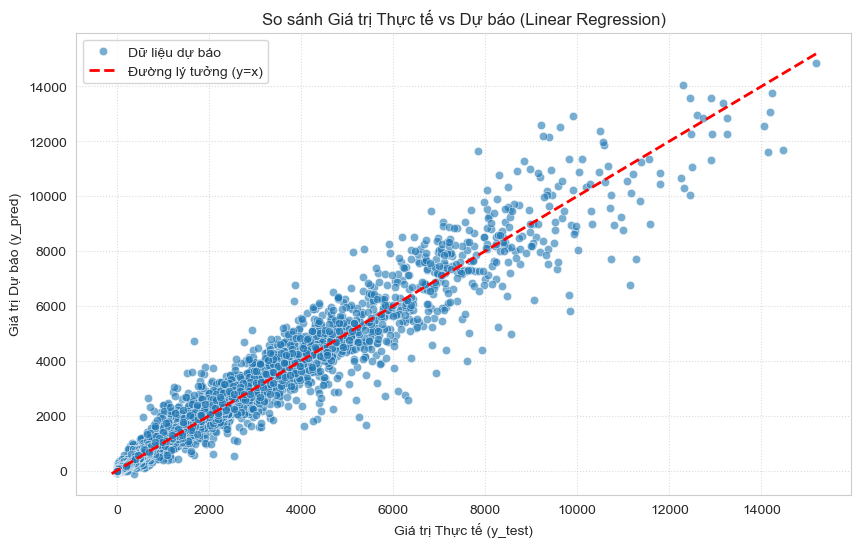

In [125]:
plot_regression_results(y_test, y_pred)

In [112]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(x_train, y_train)

xgb_pred_log = xgb_model.predict(x_test)

In [113]:
print(f"mae: {mean_absolute_error(y_test,xgb_pred_log)}")
print(f"mse: {mean_squared_error(y_test,xgb_pred_log)}")
print(f"rmse: {root_mean_squared_error(y_test,xgb_pred_log)}")
print(f"r2: {r2_score(y_test,xgb_pred_log)}")
print(f"RMSLE: {rmsle(y_test, xgb_pred_log)}")

mae: 71.34771868696467
mse: 59846.42975873291
rmse: 244.63529949443705
r2: 0.9613455650215663
RMSLE: 0.7218810859919877


In [117]:
!pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)


In [118]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves= 31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

In [119]:
lgb_model.fit(x_train, y_train)

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, random_state=42,
              subsample=0.8)

In [120]:
lgb_pred_log = lgb_model.predict(x_test)

In [121]:
print(f"mae: {mean_absolute_error(y_test,lgb_pred_log)}")
print(f"mse: {mean_squared_error(y_test,lgb_pred_log)}")
print(f"rmse: {root_mean_squared_error(y_test,lgb_pred_log)}")
print(f"r2: {r2_score(y_test,lgb_pred_log)}")
print(f"RMSLE: {rmsle(y_test, lgb_pred_log)}")

mae: 75.87799248664074
mse: 60909.469937914895
rmse: 246.79843990170377
r2: 0.9606589540131685
RMSLE: 1.0099564374335968


In [130]:
def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmsle = np.sqrt(np.mean(np.square(np.log1p(y_pred) - np.log1p(y_true))))
    
    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "RMSLE": rmsle
    }
results = []
results.append(calculate_metrics(y_test, y_pred, "Linear Regression"))
results.append(calculate_metrics(y_test, xgb_pred_log, "XGBoost"))
results.append(calculate_metrics(y_test, lgb_pred_log, "LightGBM"))

df_compare = pd.DataFrame(results)
df_compare = df_compare.round(4)


C:\Users\THIEN\AppData\Local\Temp\ipykernel_25972\3333050138.py:6: RuntimeWarning: invalid value encountered in log1p
  rmsle = np.sqrt(np.mean(np.square(np.log1p(y_pred) - np.log1p(y_true))))


In [131]:
df_compare.head()

,Model,MAE,MSE,RMSE,R2,RMSLE
0,Linear Regression,87.0733,58184.6777,241.2150,0.9624,1.1436
1,XGBoost,71.3477,59846.4298,244.6353,0.9613,0.7219
2,LightGBM,75.8780,60909.4699,246.7984,0.9607,1.0100
